In [3]:
%reset -f

## Packages and config

In [4]:
%%capture
%pip install pandas_gbq

In [5]:
#installing packages
import pandas as pd
import numpy as np
from google.cloud import bigquery
import time
from datetime import timedelta
import json
import re

import pandas_gbq
import matplotlib.pyplot as plt


In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

## Import and Clean Cirium Splunk Data

In [7]:
#import csv
df = pd.read_csv('cirium_output_20251007_20251129.csv', encoding='latin1')
df2 = pd.read_csv('cirium_output_20251130_20251229.csv', encoding='latin1')
df3 = pd.read_csv('cirium_output_20251230_20260126.csv', encoding='latin1')

In [8]:
# Common dtypes
common_dtypes = {
    "OFFER_NUMBER": "string",
    "ALERT_TYPE": "category",
    "CARRIER_NAME": "category",
    "DEP_AIRPORT": "category",
    "DEP_COUNTRY": "category",
    "Num Notifications": "int64",
}

def clean_notifications_frame(df):
    df = df.copy()
    
    # Ensure datetime
    df["Notification_Date"] = pd.to_datetime(df["Notification_Date"])
    
    df = df.astype(common_dtypes)
    return df

# Clean
df_cleaned = clean_notifications_frame(df)
df2_cleaned = clean_notifications_frame(df2)
df3_cleaned = clean_notifications_frame(df3)

# Merge
merged_df = pd.concat([df_cleaned,df2_cleaned,df3_cleaned], ignore_index=True)

In [9]:
duplicates_subset = merged_df[merged_df.duplicated(subset=['Notification_Date', 'OFFER_NUMBER', 'ALERT_TYPE', 'CARRIER_NAME', 'DEP_AIRPORT', 'DEP_COUNTRY'])]

print(f"Number of duplicates: {len(duplicates_subset)}")
print(duplicates_subset)

Number of duplicates: 0
Empty DataFrame
Columns: [Notification_Date, OFFER_NUMBER, ALERT_TYPE, CARRIER_NAME, DEP_AIRPORT, DEP_COUNTRY, Num Notifications]
Index: []


In [10]:
merged_df = merged_df[merged_df['Notification_Date']>='2025-10-11']

## Notifications by alert type

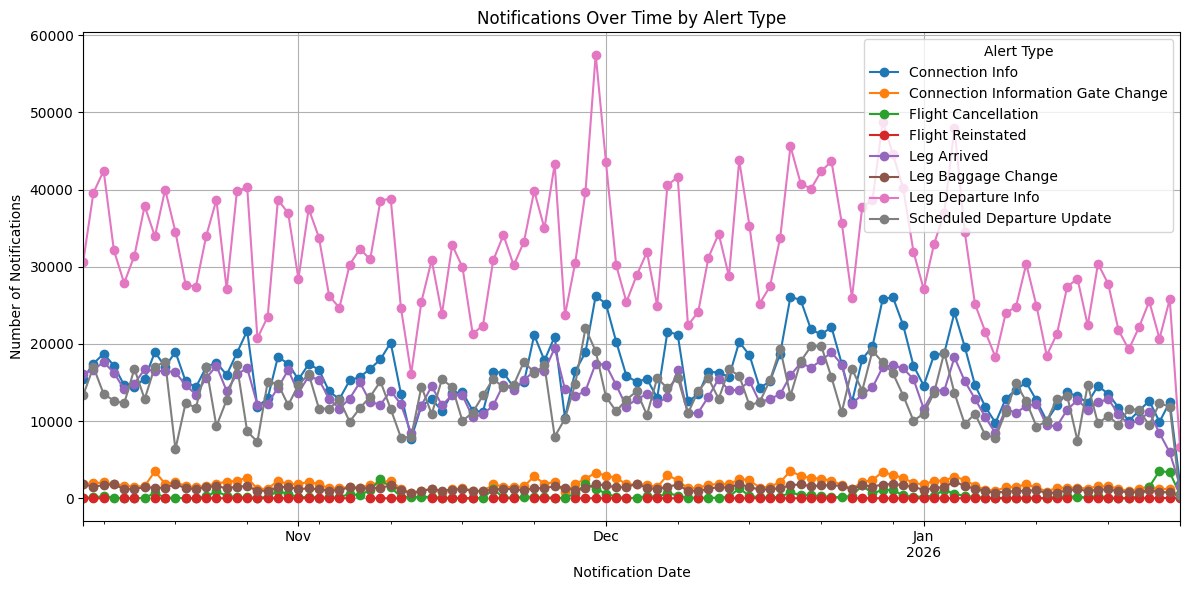

In [9]:
# Group by Notification_Date and ALERT_TYPE, and sum Num Notifications
summary = merged_df.groupby(['Notification_Date', 'ALERT_TYPE'],observed=True)['Num Notifications'].sum().reset_index()

# Pivot to make ALERT_TYPE columns and dates as index
pivot_df = summary.pivot(index='Notification_Date', columns='ALERT_TYPE', values='Num Notifications')

# Plot
pivot_df.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Notifications Over Time by Alert Type')
plt.xlabel('Notification Date')
plt.ylabel('Number of Notifications')
plt.grid(True)
plt.legend(title='Alert Type')
plt.tight_layout()
plt.show()

In [10]:
# Group by ALERT_TYPE, and sum Num Notifications
alert_summary = merged_df.groupby(['ALERT_TYPE'],observed=True)['Num Notifications'].sum().reset_index()
alert_summary.rename(columns={'Num Notifications': 'Total Notifications'}, inplace=True)

# percentage of total
total_notifications = alert_summary['Total Notifications'].sum()
alert_summary['Percentage of Total'] = (alert_summary['Total Notifications'] / total_notifications) * 100

# Avg daily notification
daily_avg = merged_df.groupby(['Notification_Date', 'ALERT_TYPE'], observed=True)['Num Notifications'].sum().reset_index()
avg_daily = daily_avg.groupby('ALERT_TYPE', observed=True)['Num Notifications'].mean().reset_index()
avg_daily.rename(columns={'Num Notifications': 'Avg Daily Notifications'}, inplace=True)

# Expected Annual
alert_summary = alert_summary.merge(avg_daily, on='ALERT_TYPE')
alert_summary['Expected Annual Notifications'] = (alert_summary['Avg Daily Notifications'] * 365).round(0)

# Round numeric values
alert_summary['Percentage of Total'] = alert_summary['Percentage of Total'].round(2)
alert_summary['Avg Daily Notifications'] = alert_summary['Avg Daily Notifications'].round(2)

In [11]:
alert_summary

,ALERT_TYPE,Total Notifications,Percentage of Total,Avg Daily Notifications,Expected Annual Notifications
0,Connection Info,1745344,20.67,16160.59,5898616.0
1,Connection Information Gate Change,195108,2.31,1806.56,659393.0
2,Flight Cancellation,44828,0.53,415.07,151502.0
3,Flight Reinstated,632,0.01,6.80,2480.0
4,Leg Arrived,1481253,17.55,13715.31,5006087.0
5,Leg Baggage Change,139642,1.65,1292.98,471938.0
6,Leg Departure Info,3409313,40.38,31567.71,11522215.0
7,Scheduled Departure Update,1426097,16.89,13204.60,4819680.0


## Upload Cirium to BQ

In [23]:
# Set up your Google Cloud project ID
project_id = 'pcln-pl-busdatasci-prod'
dataset_id = 'flight_retention'
table_id = 'cirium_output_20251011_20260126'
table_full_path = f'{project_id}.{dataset_id}.{table_id}'

# Initialize a client
client = bigquery.Client(project=project_id)

# Ensure the dataset exists (optional, create if not existing)
dataset_ref = bigquery.DatasetReference(project_id, dataset_id)
dataset = bigquery.Dataset(dataset_ref)
try:
    client.get_dataset(dataset_ref)  # Make an API request.
except NotFound:
    print('Check dataset_id')

In [24]:
pandas_gbq.to_gbq(merged_df, table_full_path, project_id=project_id, if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 11275.01it/s]


## Calculate retention, operational and performance metrics

In [12]:
sql_query = '''
select * from pcln-pl-busdatasci-prod.flight_retention.cirium_offer_all_metrics_20251117_20260105
'''

In [12]:
sql_query = '''
-- =========================
-- Parameters / Date Window
-- =========================
DECLARE retention_end_date DATE DEFAULT DATE_SUB(CURRENT_DATE('America/Toronto'), INTERVAL 1 DAY);  -- hard cut-off based on current data limit
DECLARE booking_start_date DATE DEFAULT DATE '2024-10-01';
DECLARE traveling_start_date DATE DEFAULT DATE '2025-11-17';
DECLARE traveling_end_date DATE DEFAULT DATE '2026-01-05';
DECLARE email_start_date DATE DEFAULT DATE '2025-11-04';      -- cirium email engagement from PCLN
DECLARE notification_start_date DATE DEFAULT DATE '2025-11-04';  -- cirium notifications sent from cirium
DECLARE retention_days INT64 DEFAULT 30; -- retention period from first notification

-- =========================
-- Master data table
-- =========================
WITH clean_offers AS 
(
  SELECT
      offer_id,
      MAX(offer_num) as offer_num,
      MAX(TRIM(email_address)) AS email_address,
      MAX(IFNULL(cust_new_gbl_all_flag, 'N')) AS new_booker_flag,
      MIN(product_desc) AS product_desc,
      MIN(offer_method) AS offer_type,
      MIN(air_itinerary_type_code) AS air_itinerary_type_code,
      MIN(air_carrier_name) AS air_carrier_name,
      MIN(air_ticket_type) AS air_ticket_type,
      MIN(
          CASE 
              WHEN air_dest_country_entered != 'US' AND air_orig_country_entered != 'US' THEN 'International'
              WHEN air_dest_country_entered = 'US' AND air_orig_country_entered = 'US' THEN 'Domestic'
              WHEN air_dest_country_entered != 'US' AND air_orig_country_entered = 'US' THEN 'Outbound'
              WHEN air_dest_country_entered = 'US' AND air_orig_country_entered != 'US' THEN 'Inbound'
              ELSE NULL 
          END
      ) AS air_dest_type,
      MAX(air_num_tickets) AS air_num_tickets,
      MIN(CASE WHEN gds_name = 'FLYIIN' AND air_booking_pseudo_city IN ('MFLYP00', 'MFLYP01') THEN 'MYSTIFLY' ELSE gds_name END) as gds_name,
      MIN(pcln_channel) AS pcln_channel,
      MIN(requested_cabin_class) AS requested_cabin_class,
      MIN(trans_date) AS trans_date,
      MIN(submit_date_time) AS submit_date_time,
      MIN(offer_creation_date_time) AS booking_date_time,
      MAX(travel_start_date) AS travel_start_date,
      MAX(travel_end_date) AS travel_end_date,
      MAX(advance_purchase_days) AS ap,
      MAX(length_of_stay_days) AS los,
      SUM(gr_book_amt) AS gr_book_amt,
      SUM(gr_orders) AS gr_orders,
      SUM(total_net_value) AS tnv,
      SUM(ancillary_gr_book_amt) AS ancillary_gr_book_amt
  FROM `pcln-pl-data-prod.xprod_mart.xprod_trans_day_offer_detail_v`  
  WHERE travel_start_date BETWEEN traveling_start_date AND traveling_end_date
    AND trans_date BETWEEN booking_start_date AND retention_end_date
    AND IFNULL(test_record_flag,'N') <> 'Y'
    AND gbl_partner_code = 'PCLN'
    AND gr_orders > 0
    AND gr_raw_orders > 0
    AND pkg_offer_id IS NULL
    AND (air_split_ticket_desc IS NULL OR air_split_ticket_desc = 'SPLIT')
  GROUP BY 1
  QUALIFY ROW_NUMBER() OVER (
      PARTITION BY email_address, submit_date_time 
      ORDER BY offer_id DESC
  ) = 1
),

-- =========================
-- Ancillary flags (date window aligned to main window)
-- =========================
ancillary_flags AS 
(
  SELECT
      offer_id,
      MAX(CASE WHEN ancillary_type = 'BAG'  THEN 1 ELSE 0 END) AS ancillary_bag,
      MAX(CASE WHEN ancillary_type = 'SEAT' THEN 1 ELSE 0 END) AS ancillary_seat
  FROM `pcln-pl-data-prod.cdp_base.ancillary_history_external`
  WHERE creation_date BETWEEN booking_start_date AND retention_end_date
    AND status_code IN ('CON')
    AND ancillary_type IN ('SEAT', 'BAG')
  GROUP BY offer_id
),

clean_offers_ancillary AS 
(
  SELECT
      c.*,
      CASE WHEN c.product_desc = 'AIR' THEN COALESCE(a.ancillary_bag,  0) ELSE 0 END AS ancillary_bag,
      CASE WHEN c.product_desc = 'AIR' THEN COALESCE(a.ancillary_seat, 0) ELSE 0 END AS ancillary_seat
  FROM clean_offers c
  LEFT JOIN ancillary_flags a
    ON c.offer_id = a.offer_id
),

clean_offers_segmented AS (
  SELECT
    coa.*,
    CASE coa.air_itinerary_type_code
      WHEN 'RT' THEN 'Round trip'
      WHEN 'OW' THEN 'One way'
      WHEN 'MD' THEN 'Multi Destination'
      ELSE 'Other'
    END AS itinerary_type,
    CASE WHEN coa.new_booker_flag = 'Y' THEN 'New' ELSE 'Old' END AS user_type,
    CASE
      WHEN coa.ancillary_seat = 1 AND coa.ancillary_bag = 1 THEN 'Seats and Bags'
      WHEN coa.ancillary_seat = 1 THEN 'Seats only'
      WHEN coa.ancillary_bag = 1 THEN 'Bags only'
      ELSE 'No ancillary'
    END AS ancillary_group,
    CASE WHEN coa.air_num_tickets = 1 THEN 'Single ticket' ELSE 'Multiple tickets' END AS ticket_group,
    CASE
      WHEN air_carrier_name IN (
        'Allegiant Air','Breeze Airways','Flair Air','Frontier Airlines',
        'Iberia','JetBlue Airways','Silver Airways','Spirit Airlines','Sun Country Airlines',
        'VIVA aerobus','Virgin Atlantic','Volaris'
      ) THEN 'LCC'
      WHEN air_carrier_name IN (
        'Aeromexico','Air Canada','Air France','Air India','American Airlines','Asiana Airlines',
        'Bahamasair','British Airways','Cathay Pacific','Copa','Delta Air Lines','EVA Airways',
        'Emirates Airlines','Ethiopian','Etihad Airways','Hawaiian Airlines','ITA Airways',
        'Japan Airlines','Korean Air','LATAM Airlines','Lufthansa','Philippine Airlines',
        'Porter Airlines','Qatar Airways','TACA International','TAP Portugal','Turkish Airlines',
        'United Airlines','WestJet', 'Alaska Airlines'
      ) THEN 'FSC'
      ELSE 'OTHER'
    END AS carrier_type,
    'air' AS overall_air
  FROM clean_offers_ancillary coa
),

-- =========================
-- Flight starts (EVERY AIR booking is a "snapshot" start)
-- =========================
flight_starts AS (
  SELECT
    c.offer_id,
    c.offer_num,
    c.email_address,
    c.submit_date_time,
    c.travel_start_date,
    c.offer_type,
    c.air_dest_type,
    c.user_type,
    c.itinerary_type,
    c.air_carrier_name,
    c.ancillary_group,
    c.ticket_group,
    c.gds_name,
    c.pcln_channel,
    c.requested_cabin_class,
    c.carrier_type,
    c.overall_air
  FROM clean_offers_segmented c
  WHERE c.product_desc = 'AIR'
    AND DATE(c.travel_start_date) BETWEEN traveling_start_date AND traveling_end_date
),

-- =========================
-- Cirium notifications per offer (basic pivot by ALERT_TYPE)
-- =========================
cirium_per_offer AS (
  SELECT
    OFFER_NUMBER AS offer_num,
    MIN(Notification_Date) AS first_notification_date,
    MAX(Notification_Date) AS last_notification_date,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Connection Info'
             THEN `Num Notifications` ELSE 0 END) AS notif_connection_info,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Connection Information Gate Change'
             THEN `Num Notifications` ELSE 0 END) AS notif_gate_change,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Flight Cancellation'
             THEN `Num Notifications` ELSE 0 END) AS notif_cancel,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Flight Reinstated'
             THEN `Num Notifications` ELSE 0 END) AS notif_reinstated,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Arrived'
             THEN `Num Notifications` ELSE 0 END) AS notif_arrived,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Baggage Change'
             THEN `Num Notifications` ELSE 0 END) AS notif_baggage,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Departure Info'
             THEN `Num Notifications` ELSE 0 END) AS notif_dep_info,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Scheduled Departure Update'
             THEN `Num Notifications` ELSE 0 END) AS notif_sched_dep_update,
    SUM(`Num Notifications`) AS total_notifications
  FROM `pcln-pl-busdatasci-prod.flight_retention.cirium_output_20251011_20260105`
  GROUP BY 1
),

-- =========================
-- Find the next booking of ANY product after first notification and next AIR booking after first notification and within 2 days after last notification
-- Find next booking of ANY product after first notification that is not an AIR rebooking within notification window
-- =========================
next_purchase_raw AS (
  SELECT
    fs.*,
    cpo.first_notification_date,
    cpo.last_notification_date,
    ap.submit_date_time AS next_submit_date_time,
    ap.product_desc     AS next_product_desc,

    -- Next AIR booking after first notification
    MIN(CASE WHEN ap.product_desc = 'AIR'
             THEN ap.submit_date_time
        END) OVER (
          PARTITION BY fs.email_address, fs.offer_id
        ) AS next_flight_submit_date_time,

    -- Next booking that is NOT an AIR booking within notification window or travel date window
    MIN(CASE
          WHEN NOT (
            ap.product_desc = 'AIR'
            AND DATE(ap.submit_date_time) >= COALESCE(DATE(cpo.first_notification_date),fs.travel_start_date)
            AND DATE(ap.submit_date_time) <= DATE_ADD(COALESCE(DATE(cpo.last_notification_date),fs.travel_start_date), INTERVAL 2 DAY)
          )
          THEN ap.submit_date_time
        END) OVER (
          PARTITION BY fs.email_address, fs.offer_id
        ) AS next_non_notif_flight_submit_date_time

  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  LEFT JOIN clean_offers_segmented ap
    ON ap.email_address = fs.email_address
   AND ap.submit_date_time > fs.submit_date_time           -- after original booking
   AND ap.submit_date_time > COALESCE(
         DATE(cpo.first_notification_date),
         fs.travel_start_date)                          -- after first notification or travel start date
   AND DATE(ap.submit_date_time) <= retention_end_date                   -- before cutoff
   AND TIMESTAMP_DIFF(ap.submit_date_time,
         COALESCE
          (
           DATE(cpo.first_notification_date),
           fs.travel_start_date
          ),DAY) <= retention_days  -- before retention cut-off from first notification or travel start date to next booking
   AND ap.product_desc IN ('AIR','HOTEL','RENTAL CAR','PKG','PACKAGE')   -- any product

  QUALIFY
    ap.submit_date_time IS NULL
    OR ROW_NUMBER() OVER (
         PARTITION BY fs.email_address, fs.offer_id
         ORDER BY ap.submit_date_time
       ) = 1  -- first booking of ANY product after first notification
),

next_purchase AS (
  SELECT
    *,
    CASE
      WHEN next_flight_submit_date_time IS NULL THEN 0
      WHEN next_flight_submit_date_time >= COALESCE(DATE(first_notification_date),travel_start_date)
          AND next_flight_submit_date_time <= DATE_ADD(COALESCE(DATE(last_notification_date),travel_start_date), INTERVAL 2 DAY)      -- next flight within notification window or if no notification (flight within 2 days of travel start date)
        THEN 1
      ELSE 0
    END AS next_flight_within_notification_window_flag,

  FROM next_purchase_raw
),

-- =========================
-- Customer calls between first notification (by offer_id) and 2 days AFTER last notification OR if there are no notifications between travel date and 2 days AFTER travel date
-- =========================
customer_calls AS (
  SELECT
    fs.offer_id,
    COUNT(DISTINCT log_id) AS total_calls_after_notification,
    COUNT(DISTINCT CASE WHEN cf.tlk_duration >0 THEN log_id END) AS total_calls_with_duration_after_notification,
    SUM(cf.tlk_duration) AS total_tlk_duration_after_notification,
    MIN(cf.event_date_time) AS first_call_date_time_after_notification
  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN `pcln-pl-data-prod.cares_mart.cm_event_fact` cf
    ON cf.offer_id = fs.offer_id
   AND cf.event_date_time >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
   AND cf.event_date_time <= DATE_ADD(COALESCE(cpo.last_notification_date, fs.travel_start_date), INTERVAL 2 DAY)
  GROUP BY 1
),

-- =========================
-- Penny chatbot events (email-level, bounded by query window)
-- =========================
penny_search AS
(
  SELECT
      cg.email_address AS email_address,
      pen.cguid,
      pen.user_sentiment,
      pen.conversation_id,
      TIMESTAMP(pen.creation_date) AS creation_date
  FROM `pcln-pl-data-prod.genai_penny.penny_conversation_feed_agg` pen
  JOIN `pcln-pl-data-prod.cdp_contexts.email_cguid_mapping_ranks` cg
    ON LOWER(TRIM(pen.cguid)) = LOWER(TRIM(cg.cguid))
   AND cg.latest_engagement_rank = 1
  WHERE DATE(pen.creation_date) BETWEEN notification_start_date AND retention_end_date
    AND cg.email_address IS NOT NULL
),

-- =========================
-- Penny contacts between first notification (by offer_id) and 2 days AFTER last notification OR between travel start date and 2 days after
-- =========================
penny_per_offer AS (
  SELECT
    fs.offer_id,
    COUNT(DISTINCT ps.conversation_id) AS penny_contact_count_after_notification,
    COUNT(CASE WHEN ps.user_sentiment = 'Negative' THEN ps.conversation_id END) AS penny_neg_contact_count_after_notification
  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN penny_search ps
    ON LOWER(TRIM(fs.email_address)) = LOWER(TRIM(ps.email_address))
    AND DATE(ps.creation_date) >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
    AND DATE(ps.creation_date) <= DATE_ADD(COALESCE(cpo.last_notification_date, fs.travel_start_date), INTERVAL 2 DAY)
  GROUP BY fs.offer_id
),

-- =========================
-- CSAT Scores calls after first notification OR after travel start date (BY OFFER_ID)
-- =========================
pivot_ivr_survey_response AS (
  SELECT *
  FROM (
    SELECT
      contact_id,
      creation_date,
      attr_key,
      attr_val
    FROM `pcln-pl-data-prod.cares_base.ivr_contact_trace_rec_attr_view`
    WHERE creation_date >= notification_start_date
      AND creation_date < CURRENT_DATE()
  )
  PIVOT (
    MIN(attr_val)
    FOR attr_key IN (
      'offerNumber',
      'pclnOfferNumber',
      'bestMatchTripOffered',
      'ContactId_SurveyFilled',
      'product_id',
      'productType',
      'QUEUENAME',
      'survey_result_1',
      'survey_result_2',
      'Survey_AI_Response',
      'bedrockResponse',
      'Survey_Customer_OpenFeedback',
      'customerInput',
      'Customer_Agreed_For_Survey',
      'Customer_Completed_Survey'
    )
  )
),

-- Only structure what we actually need for CSAT
ivr_call_survey_response AS (
  SELECT
    contact_id,
    creation_date,
    IFNULL(IFNULL(pclnOfferNumber, offerNumber), bestMatchTripOffered) AS offer_num,
    IFNULL(product_id, productType) AS pcln_product,
    QUEUENAME AS queue_name,
    survey_result_1,
    survey_result_2,
    IFNULL(customerInput, Survey_Customer_OpenFeedback) AS customer_open_feedback,
    IFNULL(bedrockResponse, Survey_AI_Response) AS survey_ai_response
  FROM pivot_ivr_survey_response
  WHERE
    (creation_date >= DATE('2025-01-01')  AND creation_date < DATE('2025-11-03'))
    AND Customer_Agreed_For_Survey = 'true'
    AND Customer_Completed_Survey = 'true'

  UNION ALL

  SELECT
    contact_id,
    creation_date,
    IFNULL(IFNULL(pclnOfferNumber, offerNumber), bestMatchTripOffered) AS offer_num,
    IFNULL(product_id, productType) AS pcln_product,
    QUEUENAME AS queue_name,
    survey_result_1,
    survey_result_2,
    IFNULL(customerInput, Survey_Customer_OpenFeedback) AS customer_open_feedback,
    IFNULL(bedrockResponse, Survey_AI_Response) AS survey_ai_response
  FROM pivot_ivr_survey_response
  WHERE
    creation_date >= DATE('2025-11-03')
    AND Customer_Agreed_For_Survey = 'true'
    AND Customer_Completed_Survey = 'true'
    AND contact_id IN (
      SELECT ContactId_SurveyFilled
      FROM pivot_ivr_survey_response
      WHERE Customer_Agreed_For_Survey = 'true'
        AND Customer_Completed_Survey = 'true'
    )
),

-- Only keep what’s necessary to filter on valid calls (queue_name) and keep creation_date
inbound_callback_transfer_calls AS (
  SELECT DISTINCT
    contact_id,
    queue
  FROM `pcln-pl-data-prod.cares_base.ivr_contact_trace_rec`
  WHERE 
    creation_date >= DATE('2025-01-01')
    AND creation_date < CURRENT_DATE()
    AND (
      (initiation_method = 'INBOUND' AND disconnect_reason <> 'CONTACT_FLOW_DISCONNECT') OR
      (initiation_method = 'CALLBACK' AND disconnect_reason IS NOT NULL) OR
      (initiation_method = 'TRANSFER' AND disconnect_reason <> 'CONTACT_FLOW_DISCONNECT')
    )
),

-- Minimal join of IVR survey + valid call traces
ivr_complete_data AS (
  SELECT
    icsr.contact_id,
    icsr.creation_date,
    icsr.offer_num,
    icsr.pcln_product,
    IFNULL(icsr.queue_name, ictc.queue) AS queue_name,
    icsr.survey_result_1,
    icsr.survey_result_2,
    icsr.customer_open_feedback,
    icsr.survey_ai_response
  FROM ivr_call_survey_response icsr
  INNER JOIN inbound_callback_transfer_calls ictc
    ON icsr.contact_id = ictc.contact_id
),

-- Filter to non-abandoned/contained calls via queue_name
ivr_survey_reason AS (
  SELECT
    icd.contact_id,
    icd.creation_date,
    icd.offer_num,
    icd.pcln_product,
    icd.survey_result_1,
    icd.survey_result_2,
    icd.customer_open_feedback,
    icd.survey_ai_response
  FROM ivr_complete_data icd
  WHERE icd.queue_name IS NOT NULL
),

csat_score AS (
  SELECT
    isr.contact_id,
    isr.creation_date,
    isr.offer_num,
    isr.pcln_product,
    SAFE_CAST(isr.survey_result_1 AS FLOAT64) AS survey_result_1,
    SAFE_CAST(isr.survey_result_2 AS FLOAT64) AS survey_result_2,
    SAFE_DIVIDE(
      COALESCE(SAFE_CAST(isr.survey_result_1 AS FLOAT64), 0) + 
      COALESCE(SAFE_CAST(isr.survey_result_2 AS FLOAT64), 0),
      (CASE WHEN SAFE_CAST(isr.survey_result_1 AS FLOAT64) IS NOT NULL THEN 1 ELSE 0 END + 
       CASE WHEN SAFE_CAST(isr.survey_result_2 AS FLOAT64) IS NOT NULL THEN 1 ELSE 0 END)
    ) AS avg_csat_score,
    isr.customer_open_feedback,
    isr.survey_ai_response
  FROM ivr_survey_reason isr
  JOIN flight_starts fs
    ON CAST(isr.offer_num AS INT64) = fs.offer_num
  LEFT JOIN cirium_per_offer cpo
    ON isr.offer_num = cpo.offer_num
    AND isr.creation_date >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY isr.contact_id
    ORDER BY isr.creation_date
  ) = 1
),

csat_score_by_offer AS (
  SELECT
    offer_num,
    AVG(survey_result_1) AS avg_survey_result_1,
    AVG(survey_result_2) AS avg_survey_result_2,
    AVG(avg_csat_score) AS avg_csat_score_by_offer,
    COUNT(*) AS n_surveys
  FROM csat_score
  GROUP BY offer_num
),

-- =========================
-- email engagement by offer_id, email address
-- =========================
email_engagement AS (
  SELECT
    fs.offer_id,
    COUNT(CASE WHEN eg.action_type = 'CLICK' THEN 1 END) AS email_clicks,
    COUNT(CASE WHEN eg.action_type = 'OPEN'  THEN 1 END) AS email_opens
  FROM flight_starts fs
  JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN `pcln-pl-data-prod.email_mktg_xform.email_engagement` eg
    ON UPPER(TRIM(fs.email_address)) = UPPER(TRIM(eg.email_address))
  WHERE
    eg.refid_query_string = 'TM|PCLN|OFFER|FLIGHT_ALERT|1'
    AND eg.date_time >= TIMESTAMP(email_start_date)

    -- Additional logic tying emails to notification window
    AND eg.date_time >= TIMESTAMP(cpo.first_notification_date)
    AND eg.date_time <= TIMESTAMP_ADD(TIMESTAMP(cpo.last_notification_date), INTERVAL 2 DAY)
  GROUP BY
    fs.offer_id
),

-- =========================
-- Final offer-level output
-- =========================
offer_level AS (
  SELECT
    np.offer_id,
    np.offer_num,
    np.email_address,
    np.submit_date_time,
    np.travel_start_date,
    np.offer_type,
    np.air_dest_type,
    np.user_type,
    np.itinerary_type,
    np.air_carrier_name,
    np.ancillary_group,
    np.ticket_group,
    np.gds_name,
    np.pcln_channel,
    np.requested_cabin_class,
    np.carrier_type,
    np.overall_air,

    -- next purchase info
    np.next_product_desc,
    np.next_submit_date_time AS next_purchase_date,
    DATE_DIFF(
      DATE(np.next_submit_date_time),
      DATE(np.first_notification_date),
      DAY
    ) AS days_after_first_notification_to_next_purchase,
    np.next_flight_submit_date_time,
    np.next_flight_within_notification_window_flag,
    np.next_non_notif_flight_submit_date_time,

    -- customer call metrics
    cc.total_calls_after_notification,
    cc.total_calls_with_duration_after_notification,
    cc.total_tlk_duration_after_notification,
    cc.first_call_date_time_after_notification,
    
    --csat scores
    csat.avg_survey_result_1,
    csat.avg_survey_result_2,
    csat.avg_csat_score_by_offer,
    csat.n_surveys,

    -- Penny chatbot metrics
    pp.penny_contact_count_after_notification,
    pp.penny_neg_contact_count_after_notification,

    -- Notification email engagement metrics
    eg.email_clicks,
    eg.email_opens,

    -- Cirium notification metrics
    cp.first_notification_date,
    cp.last_notification_date,
    cp.notif_connection_info,
    cp.notif_gate_change,
    cp.notif_cancel,
    cp.notif_reinstated,
    cp.notif_arrived,
    cp.notif_baggage,
    cp.notif_dep_info,
    cp.notif_sched_dep_update,
    cp.total_notifications,

  FROM next_purchase np
  LEFT JOIN customer_calls cc
    ON np.offer_id = cc.offer_id
  LEFT JOIN penny_per_offer pp
    ON np.offer_id = pp.offer_id
  LEFT JOIN cirium_per_offer cp
    ON np.offer_num = CAST(cp.offer_num AS INT64)
  LEFT JOIN csat_score_by_offer csat
    ON CAST(csat.offer_num AS INT64) = np.offer_num
  LEFT JOIN email_engagement eg
    ON np.offer_id = eg.offer_id
    )

SELECT *
FROM offer_level
;
'''

In [11]:
sql_query = '''
-- =========================
-- Parameters / Date Window
-- =========================
DECLARE retention_end_date DATE DEFAULT DATE_SUB(CURRENT_DATE('America/Toronto'), INTERVAL 1 DAY);  -- hard cut-off based on current data limit
DECLARE booking_start_date DATE DEFAULT DATE '2024-10-01';
DECLARE traveling_start_date DATE DEFAULT DATE '2025-11-17';
DECLARE traveling_end_date DATE DEFAULT DATE_SUB(CURRENT_DATE('America/Toronto'), INTERVAL 32 DAY);
DECLARE email_start_date DATE DEFAULT DATE '2025-11-04';      -- cirium email engagement from PCLN
DECLARE history_email_start_date DATE DEFAULT DATE '2024-11-04';      -- historical email engagement from PCLN
DECLARE notification_start_date DATE DEFAULT DATE '2025-11-04';  -- cirium notifications sent from cirium
DECLARE retention_days INT64 DEFAULT 30; -- retention period from first notification

-- =========================
-- Master data table
-- =========================
WITH clean_offers AS 
(
  SELECT
      offer_id,
      MAX(offer_num) as offer_num,
      MAX(TRIM(email_address)) AS email_address,
      MAX(IFNULL(cust_new_gbl_all_flag, 'N')) AS new_booker_flag,
      MIN(product_desc) AS product_desc,
      MIN(offer_method) AS offer_type,
      MIN(air_itinerary_type_code) AS air_itinerary_type_code,
      MIN(air_carrier_name) AS air_carrier_name,
      MIN(air_ticket_type) AS air_ticket_type,
      MIN(
          CASE 
              WHEN air_dest_country_entered != 'US' AND air_orig_country_entered != 'US' THEN 'International'
              WHEN air_dest_country_entered = 'US' AND air_orig_country_entered = 'US' THEN 'Domestic'
              WHEN air_dest_country_entered != 'US' AND air_orig_country_entered = 'US' THEN 'Outbound'
              WHEN air_dest_country_entered = 'US' AND air_orig_country_entered != 'US' THEN 'Inbound'
              ELSE NULL 
          END
      ) AS air_dest_type,
      MAX(air_num_tickets) AS air_num_tickets,
      MIN(
          CASE 
                WHEN gds_name = 'FLYIIN' AND air_booking_pseudo_city IN ('MFLYP00', 'MFLYP01') THEN 'MYSTIFLY' 
                WHEN air_booking_pseudo_city IN ('DIDAP01') then 'DIDA'
                WHEN air_booking_pseudo_city IN ('NYCPZ28AT') then 'AMADEUS-NDCX'
                WHEN air_booking_pseudo_city IN ('GTT') then 'PHONE_SALES'
                ELSE gds_name 
          END
      ) AS gds_name,
      MIN(pcln_channel) AS pcln_channel,
      MIN(requested_cabin_class) AS requested_cabin_class,
      MAX(CASE WHEN product_group_desc LIKE ('%PKG%') THEN 1 ELSE 0 END) AS pkg_flag,
      MIN(trans_date) AS trans_date,
      MIN(submit_date_time) AS submit_date_time,
      MIN(offer_creation_date_time) AS booking_date_time,
      MAX(travel_start_date) AS travel_start_date,
      MAX(travel_end_date) AS travel_end_date,
      MAX(advance_purchase_days) AS ap,
      MAX(length_of_stay_days) AS los,
      SUM(gr_book_amt) AS gr_book_amt,
      SUM(gr_orders) AS gr_orders,
      SUM(total_net_value) AS tnv,
      SUM(ancillary_gr_book_amt) AS ancillary_gr_book_amt
  FROM `pcln-pl-data-prod.xprod_mart.xprod_trans_day_offer_detail_v`  
  WHERE travel_start_date BETWEEN traveling_start_date AND traveling_end_date
    AND trans_date BETWEEN booking_start_date AND retention_end_date
    AND IFNULL(test_record_flag,'N') <> 'Y'
    AND gbl_partner_code = 'PCLN'
    AND gr_orders > 0
    AND gr_raw_orders > 0
    AND REF_UNITS >= 0
    AND pkg_offer_id IS NULL
    AND (air_split_ticket_desc IS NULL OR air_split_ticket_desc = 'SPLIT')
  GROUP BY 1
  QUALIFY ROW_NUMBER() OVER (
      PARTITION BY email_address, submit_date_time 
      ORDER BY offer_id DESC
  ) = 1
),

-- =========================
-- Ancillary flags (date window aligned to main window)
-- =========================
ancillary_flags AS 
(
  SELECT
      offer_id,
      MAX(CASE WHEN ancillary_type = 'BAG'  THEN 1 ELSE 0 END) AS ancillary_bag,
      MAX(CASE WHEN ancillary_type = 'SEAT' THEN 1 ELSE 0 END) AS ancillary_seat
  FROM `pcln-pl-data-prod.cdp_base.ancillary_history_external`
  WHERE creation_date BETWEEN booking_start_date AND retention_end_date
    AND status_code IN ('CON')
    AND ancillary_type IN ('SEAT', 'BAG')
  GROUP BY offer_id
),

clean_offers_ancillary AS 
(
  SELECT
      c.*,
      CASE WHEN c.product_desc = 'AIR' THEN COALESCE(a.ancillary_bag,  0) ELSE 0 END AS ancillary_bag,
      CASE WHEN c.product_desc = 'AIR' THEN COALESCE(a.ancillary_seat, 0) ELSE 0 END AS ancillary_seat
  FROM clean_offers c
  LEFT JOIN ancillary_flags a
    ON c.offer_id = a.offer_id
),

clean_offers_segmented AS (
  SELECT
    coa.*,
    CASE coa.air_itinerary_type_code
      WHEN 'RT' THEN 'Round trip'
      WHEN 'OW' THEN 'One way'
      WHEN 'MD' THEN 'Multi Destination'
      ELSE 'Other'
    END AS itinerary_type,
    CASE WHEN coa.new_booker_flag = 'Y' THEN 'New' ELSE 'Old' END AS user_type,
    CASE
      WHEN coa.ancillary_seat = 1 AND coa.ancillary_bag = 1 THEN 'Seats and Bags'
      WHEN coa.ancillary_seat = 1 THEN 'Seats only'
      WHEN coa.ancillary_bag = 1 THEN 'Bags only'
      ELSE 'No ancillary'
    END AS ancillary_group,
    CASE WHEN coa.air_num_tickets = 1 THEN 'Single ticket' ELSE 'Multiple tickets' END AS ticket_group,
    CASE
      WHEN air_carrier_name IN (
        'Allegiant Air','Breeze Airways','Flair Air','Frontier Airlines',
        'Iberia','JetBlue Airways','Silver Airways','Spirit Airlines','Sun Country Airlines',
        'VIVA aerobus','Virgin Atlantic','Volaris'
      ) THEN 'LCC'
      WHEN air_carrier_name IN (
        'Aeromexico','Air Canada','Air France','Air India','American Airlines','Asiana Airlines',
        'Bahamasair','British Airways','Cathay Pacific','Copa','Delta Air Lines','EVA Airways',
        'Emirates Airlines','Ethiopian','Etihad Airways','Hawaiian Airlines','ITA Airways',
        'Japan Airlines','Korean Air','LATAM Airlines','Lufthansa','Philippine Airlines',
        'Porter Airlines','Qatar Airways','TACA International','TAP Portugal','Turkish Airlines',
        'United Airlines','WestJet', 'Alaska Airlines'
      ) THEN 'FSC'
      ELSE 'OTHER'
    END AS carrier_type,
    'air' AS overall_air
  FROM clean_offers_ancillary coa
),

-- =========================
-- Flight starts (EVERY AIR booking is a "snapshot" start)
-- =========================
flight_starts AS (
  SELECT
    c.offer_id,
    c.offer_num,
    c.email_address,
    c.submit_date_time,
    c.travel_start_date,
    c.offer_type,
    c.air_dest_type,
    c.user_type,
    c.itinerary_type,
    c.air_carrier_name,
    c.ancillary_group,
    c.ticket_group,
    c.gds_name,
    c.pcln_channel,
    c.requested_cabin_class,
    c.pkg_flag,
    c.carrier_type,
    c.overall_air
  FROM clean_offers_segmented c
  WHERE c.product_desc = 'AIR'
    AND DATE(c.travel_start_date) BETWEEN traveling_start_date AND traveling_end_date
),

-- =========================
-- Cirium notifications per offer (basic pivot by ALERT_TYPE)
-- =========================
cirium_per_offer AS (
  SELECT
    OFFER_NUMBER AS offer_num,
    MIN(Notification_Date) AS first_notification_date,
    MAX(Notification_Date) AS last_notification_date,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Connection Info'
             THEN `Num Notifications` ELSE 0 END) AS notif_connection_info,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Connection Information Gate Change'
             THEN `Num Notifications` ELSE 0 END) AS notif_gate_change,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Flight Cancellation'
             THEN `Num Notifications` ELSE 0 END) AS notif_cancel,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Flight Reinstated'
             THEN `Num Notifications` ELSE 0 END) AS notif_reinstated,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Arrived'
             THEN `Num Notifications` ELSE 0 END) AS notif_arrived,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Baggage Change'
             THEN `Num Notifications` ELSE 0 END) AS notif_baggage,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Leg Departure Info'
             THEN `Num Notifications` ELSE 0 END) AS notif_dep_info,
    SUM(CASE WHEN CAST(ALERT_TYPE AS STRING) = 'Scheduled Departure Update'
             THEN `Num Notifications` ELSE 0 END) AS notif_sched_dep_update,
    SUM(`Num Notifications`) AS total_notifications
  FROM `pcln-pl-busdatasci-prod.flight_retention.cirium_output_20251011_20260126`
  GROUP BY 1
),

-- =========================
-- Find the next booking of ANY product after first notification and next AIR booking after first notification and within 2 days after last notification
-- Find next booking of ANY product after first notification that is not an AIR rebooking within notification window
-- =========================
next_purchase_raw AS (
  SELECT
    fs.*,
    cpo.first_notification_date,
    cpo.last_notification_date,
    ap.submit_date_time AS next_submit_date_time,
    ap.product_desc     AS next_product_desc,

    -- Next AIR booking after first notification
    MIN(CASE WHEN ap.product_desc = 'AIR'
             THEN ap.submit_date_time
        END) OVER (
          PARTITION BY fs.email_address, fs.offer_id
        ) AS next_flight_submit_date_time,

    -- Next booking that is NOT an AIR booking within notification window or travel date window
    MIN(CASE
          WHEN NOT (
            ap.product_desc = 'AIR'
            AND DATE(ap.submit_date_time) >= fs.travel_start_date
            AND DATE(ap.submit_date_time) <= DATE_ADD(fs.travel_start_date, INTERVAL 2 DAY)
          )
          THEN ap.submit_date_time
        END) OVER (
          PARTITION BY fs.email_address, fs.offer_id
        ) AS next_non_notif_flight_submit_date_time

  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  LEFT JOIN clean_offers_segmented ap
    ON ap.email_address = fs.email_address
   AND ap.submit_date_time > fs.submit_date_time           -- after original booking
   AND ap.submit_date_time > fs.travel_start_date                          -- after first notification or travel start date
   AND DATE(ap.submit_date_time) <= retention_end_date                   -- before cutoff
   AND TIMESTAMP_DIFF(ap.submit_date_time,
           fs.travel_start_date,DAY) <= retention_days  -- before retention cut-off from first notification or travel start date to next booking
   AND ap.product_desc IN ('AIR','HOTEL','RENTAL CAR','PKG','PACKAGE')   -- any product

  QUALIFY
    ap.submit_date_time IS NULL
    OR ROW_NUMBER() OVER (
         PARTITION BY fs.email_address, fs.offer_id
         ORDER BY ap.submit_date_time
       ) = 1  -- first booking of ANY product after first notification
),

next_purchase AS (
  SELECT
    *,
    CASE
      WHEN next_flight_submit_date_time IS NULL THEN 0
      WHEN next_flight_submit_date_time >= COALESCE(DATE(first_notification_date),travel_start_date)
          AND next_flight_submit_date_time <= DATE_ADD(COALESCE(DATE(last_notification_date),travel_start_date), INTERVAL 2 DAY)      -- next flight within notification window or if no notification (flight within 2 days of travel start date)
        THEN 1
      ELSE 0
    END AS next_flight_within_notification_window_flag,

  FROM next_purchase_raw
),

-- =========================
-- Customer calls between first notification (by offer_id) and 2 days AFTER last notification OR if there are no notifications between travel date and 2 days AFTER travel date
-- =========================
customer_calls AS (
  SELECT
    fs.offer_id,
    COUNT(DISTINCT log_id) AS total_calls_after_notification,
    COUNT(DISTINCT CASE WHEN cf.tlk_duration >0 THEN log_id END) AS total_calls_with_duration_after_notification,
    SUM(cf.tlk_duration) AS total_tlk_duration_after_notification,
    MIN(cf.event_date_time) AS first_call_date_time_after_notification
  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN `pcln-pl-data-prod.cares_mart.cm_event_fact` cf
    ON cf.offer_id = fs.offer_id
   AND cf.event_date_time >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
   AND cf.event_date_time <= DATE_ADD(COALESCE(cpo.last_notification_date, fs.travel_start_date), INTERVAL 2 DAY)
  GROUP BY 1
),

-- =========================
-- Penny chatbot events (email-level, bounded by query window)
-- =========================
penny_search AS
(
  SELECT
      cg.email_address AS email_address,
      pen.cguid,
      pen.user_sentiment,
      pen.conversation_id,
      TIMESTAMP(pen.creation_date) AS creation_date
  FROM `pcln-pl-data-prod.genai_penny.penny_conversation_feed_agg` pen
  JOIN `pcln-pl-data-prod.cdp_contexts.email_cguid_mapping_ranks` cg
    ON LOWER(TRIM(pen.cguid)) = LOWER(TRIM(cg.cguid))
   AND cg.latest_engagement_rank = 1
  WHERE DATE(pen.creation_date) BETWEEN notification_start_date AND retention_end_date
    AND cg.email_address IS NOT NULL
),

-- =========================
-- Penny contacts between first notification (by offer_id) and 2 days AFTER last notification OR between travel start date and 2 days after
-- =========================
penny_per_offer AS (
  SELECT
    fs.offer_id,
    COUNT(DISTINCT ps.conversation_id) AS penny_contact_count_after_notification,
    COUNT(CASE WHEN ps.user_sentiment = 'Negative' THEN ps.conversation_id END) AS penny_neg_contact_count_after_notification
  FROM flight_starts fs
  LEFT JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN penny_search ps
    ON LOWER(TRIM(fs.email_address)) = LOWER(TRIM(ps.email_address))
    AND DATE(ps.creation_date) >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
    AND DATE(ps.creation_date) <= DATE_ADD(COALESCE(cpo.last_notification_date, fs.travel_start_date), INTERVAL 2 DAY)
  GROUP BY fs.offer_id
),

-- =========================
-- CSAT Scores calls after first notification OR after travel start date (BY OFFER_ID)
-- =========================
pivot_ivr_survey_response AS (
  SELECT *
  FROM (
    SELECT
      contact_id,
      creation_date,
      attr_key,
      attr_val
    FROM `pcln-pl-data-prod.cares_base.ivr_contact_trace_rec_attr_view`
    WHERE creation_date >= notification_start_date
      AND creation_date < CURRENT_DATE()
  )
  PIVOT (
    MIN(attr_val)
    FOR attr_key IN (
      'offerNumber',
      'pclnOfferNumber',
      'bestMatchTripOffered',
      'ContactId_SurveyFilled',
      'product_id',
      'productType',
      'QUEUENAME',
      'survey_result_1',
      'survey_result_2',
      'Survey_AI_Response',
      'bedrockResponse',
      'Survey_Customer_OpenFeedback',
      'customerInput',
      'Customer_Agreed_For_Survey',
      'Customer_Completed_Survey'
    )
  )
),

-- Only structure what we actually need for CSAT
ivr_call_survey_response AS (
  SELECT
    contact_id,
    creation_date,
    IFNULL(IFNULL(pclnOfferNumber, offerNumber), bestMatchTripOffered) AS offer_num,
    IFNULL(product_id, productType) AS pcln_product,
    QUEUENAME AS queue_name,
    survey_result_1,
    survey_result_2,
    IFNULL(customerInput, Survey_Customer_OpenFeedback) AS customer_open_feedback,
    IFNULL(bedrockResponse, Survey_AI_Response) AS survey_ai_response
  FROM pivot_ivr_survey_response
  WHERE
    (creation_date >= DATE('2025-01-01')  AND creation_date < DATE('2025-11-03'))
    AND Customer_Agreed_For_Survey = 'true'
    AND Customer_Completed_Survey = 'true'

  UNION ALL

  SELECT
    contact_id,
    creation_date,
    IFNULL(IFNULL(pclnOfferNumber, offerNumber), bestMatchTripOffered) AS offer_num,
    IFNULL(product_id, productType) AS pcln_product,
    QUEUENAME AS queue_name,
    survey_result_1,
    survey_result_2,
    IFNULL(customerInput, Survey_Customer_OpenFeedback) AS customer_open_feedback,
    IFNULL(bedrockResponse, Survey_AI_Response) AS survey_ai_response
  FROM pivot_ivr_survey_response
  WHERE
    creation_date >= DATE('2025-11-03')
    AND Customer_Agreed_For_Survey = 'true'
    AND Customer_Completed_Survey = 'true'
    AND contact_id IN (
      SELECT ContactId_SurveyFilled
      FROM pivot_ivr_survey_response
      WHERE Customer_Agreed_For_Survey = 'true'
        AND Customer_Completed_Survey = 'true'
    )
),

-- Only keep what’s necessary to filter on valid calls (queue_name) and keep creation_date
inbound_callback_transfer_calls AS (
  SELECT DISTINCT
    contact_id,
    queue
  FROM `pcln-pl-data-prod.cares_base.ivr_contact_trace_rec`
  WHERE 
    creation_date >= DATE('2025-01-01')
    AND creation_date < CURRENT_DATE()
    AND (
      (initiation_method = 'INBOUND' AND disconnect_reason <> 'CONTACT_FLOW_DISCONNECT') OR
      (initiation_method = 'CALLBACK' AND disconnect_reason IS NOT NULL) OR
      (initiation_method = 'TRANSFER' AND disconnect_reason <> 'CONTACT_FLOW_DISCONNECT')
    )
),

-- Minimal join of IVR survey + valid call traces
ivr_complete_data AS (
  SELECT
    icsr.contact_id,
    icsr.creation_date,
    icsr.offer_num,
    icsr.pcln_product,
    IFNULL(icsr.queue_name, ictc.queue) AS queue_name,
    icsr.survey_result_1,
    icsr.survey_result_2,
    icsr.customer_open_feedback,
    icsr.survey_ai_response
  FROM ivr_call_survey_response icsr
  INNER JOIN inbound_callback_transfer_calls ictc
    ON icsr.contact_id = ictc.contact_id
),

-- Filter to non-abandoned/contained calls via queue_name
ivr_survey_reason AS (
  SELECT
    icd.contact_id,
    icd.creation_date,
    icd.offer_num,
    icd.pcln_product,
    icd.survey_result_1,
    icd.survey_result_2,
    icd.customer_open_feedback,
    icd.survey_ai_response
  FROM ivr_complete_data icd
  WHERE icd.queue_name IS NOT NULL
),

csat_score AS (
  SELECT
    isr.contact_id,
    isr.creation_date,
    SAFE_CAST(isr.offer_num AS INT64) AS offer_num,
    isr.pcln_product,
    SAFE_CAST(isr.survey_result_1 AS FLOAT64) AS survey_result_1,
    SAFE_CAST(isr.survey_result_2 AS FLOAT64) AS survey_result_2,
    SAFE_DIVIDE(
      COALESCE(SAFE_CAST(isr.survey_result_1 AS FLOAT64), 0) + 
      COALESCE(SAFE_CAST(isr.survey_result_2 AS FLOAT64), 0),
      (CASE WHEN SAFE_CAST(isr.survey_result_1 AS FLOAT64) IS NOT NULL THEN 1 ELSE 0 END + 
       CASE WHEN SAFE_CAST(isr.survey_result_2 AS FLOAT64) IS NOT NULL THEN 1 ELSE 0 END)
    ) AS avg_csat_score,
    isr.customer_open_feedback,
    isr.survey_ai_response
  FROM ivr_survey_reason isr
  JOIN flight_starts fs
    ON SAFE_CAST(isr.offer_num AS INT64) = fs.offer_num
  LEFT JOIN cirium_per_offer cpo
    ON isr.offer_num = cpo.offer_num
    AND isr.creation_date >= COALESCE(cpo.first_notification_date, fs.travel_start_date)
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY isr.contact_id
    ORDER BY isr.creation_date
  ) = 1
),

csat_score_by_offer AS (
  SELECT
    offer_num,
    AVG(survey_result_1) AS avg_survey_result_1,
    AVG(survey_result_2) AS avg_survey_result_2,
    AVG(avg_csat_score) AS avg_csat_score_by_offer,
    COUNT(*) AS n_surveys
  FROM csat_score
  GROUP BY offer_num
),

-- =========================
-- email engagement by offer_id, email address
-- =========================
email_engagement AS (
  SELECT
    fs.offer_id,
    COUNT(CASE WHEN eg.action_type = 'CLICK' THEN 1 END) AS email_clicks,
    COUNT(CASE WHEN eg.action_type = 'OPEN'  THEN 1 END) AS email_opens
  FROM flight_starts fs
  JOIN cirium_per_offer cpo
    ON CAST(cpo.offer_num AS INT64) = fs.offer_num
  JOIN `pcln-pl-data-prod.email_mktg_xform.email_engagement` eg
    ON UPPER(TRIM(fs.email_address)) = UPPER(TRIM(eg.email_address))
  WHERE
    eg.refid_query_string = 'TM|PCLN|OFFER|FLIGHT_ALERT|1'
    AND eg.date_time >= TIMESTAMP(email_start_date)

    -- Additional logic tying emails to notification window
    AND eg.date_time >= TIMESTAMP(cpo.first_notification_date)
    AND eg.date_time <= TIMESTAMP_ADD(TIMESTAMP(cpo.last_notification_date), INTERVAL 2 DAY)
  GROUP BY
    fs.offer_id
),

-- =========================
-- historical email engagement by offer_id, email address
-- =========================
history_email_engagement AS (
  SELECT
    fs.offer_id
  FROM flight_starts fs
  JOIN `pcln-pl-data-prod.email_mktg_xform.email_engagement` eg
    ON UPPER(TRIM(fs.email_address)) = UPPER(TRIM(eg.email_address))
  WHERE
    eg.date_time >= TIMESTAMP(history_email_start_date)
    AND eg.date_time >= TIMESTAMP_SUB(TIMESTAMP(fs.submit_date_time), INTERVAL 365 DAY)
    AND eg.date_time < TIMESTAMP(fs.submit_date_time)
  GROUP BY
    fs.offer_id
),

-- =========================
-- Final offer-level output
-- =========================
offer_level AS (
  SELECT
    np.offer_id,
    np.offer_num,
    np.email_address,
    np.submit_date_time,
    np.travel_start_date,
    np.offer_type,
    np.air_dest_type,
    np.user_type,
    np.itinerary_type,
    np.air_carrier_name,
    np.ancillary_group,
    np.ticket_group,
    np.gds_name,
    np.pcln_channel,
    np.requested_cabin_class,
--    np.pkg_flag,
    np.carrier_type,
    np.overall_air,

    -- next purchase info
    np.next_product_desc,
    np.next_submit_date_time AS next_purchase_date,
    DATE_DIFF(
      DATE(np.next_submit_date_time),
      DATE(np.first_notification_date),
      DAY
    ) AS days_after_first_notification_to_next_purchase,
    np.next_flight_submit_date_time,
    np.next_flight_within_notification_window_flag,
    np.next_non_notif_flight_submit_date_time,

    -- customer call metrics
    cc.total_calls_after_notification,
    cc.total_calls_with_duration_after_notification,
    cc.total_tlk_duration_after_notification,
    cc.first_call_date_time_after_notification,
    
    --csat scores
    csat.avg_survey_result_1,
    csat.avg_survey_result_2,
    csat.avg_csat_score_by_offer,
    csat.n_surveys,

    -- Penny chatbot metrics
    pp.penny_contact_count_after_notification,
    pp.penny_neg_contact_count_after_notification,

    -- Notification email engagement metrics
    eg.email_clicks,
    eg.email_opens,
    CASE WHEN heg.offer_id IS NOT NULL THEN 1 ELSE 0 END AS past_yr_email_engagement,

    -- Cirium notification metrics
    cp.first_notification_date,
    cp.last_notification_date,
    cp.notif_connection_info,
    cp.notif_gate_change,
    cp.notif_cancel,
    cp.notif_reinstated,
    cp.notif_arrived,
    cp.notif_baggage,
    cp.notif_dep_info,
    cp.notif_sched_dep_update,
    cp.total_notifications,

  FROM next_purchase np
  LEFT JOIN customer_calls cc
    ON np.offer_id = cc.offer_id
  LEFT JOIN penny_per_offer pp
    ON np.offer_id = pp.offer_id
  LEFT JOIN cirium_per_offer cp
    ON np.offer_num = CAST(cp.offer_num AS INT64)
  LEFT JOIN csat_score_by_offer csat
    ON CAST(csat.offer_num AS INT64) = np.offer_num
  LEFT JOIN email_engagement eg
    ON np.offer_id = eg.offer_id
  LEFT JOIN history_email_engagement heg
    ON np.offer_id = heg.offer_id
    )
    
SELECT *
FROM offer_level
;
'''

In [12]:
project_id = 'pcln-pl-busdatasci-prod'

# Initialize a BigQuery client
bq_client = bigquery.Client(project=project_id)

# Execute the query
job = bq_client.query(sql_query)
master_df = job.to_dataframe()

In [13]:
# --- ID fields: nullable integers ---
id_cols = ["offer_id", "offer_num"]

for col in id_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce").astype("Int64")

# --- Datetime columns ---
datetime_cols = [
    "submit_date_time",
    "travel_start_date",
    "next_purchase_date",
    "next_flight_submit_date_time",
    "next_non_notif_flight_submit_date_time",
    "first_call_date_time_after_notification",
    "first_notification_date",
    "last_notification_date",
]

for col in datetime_cols:
    master_df[col] = pd.to_datetime(master_df[col], errors="coerce")

# --- Notification count columns: force nullable integer types ---
notif_cols = [
    "notif_connection_info",
    "notif_gate_change",
    "notif_cancel",
    "notif_reinstated",
    "notif_arrived",
    "notif_baggage",
    "notif_dep_info",
    "notif_sched_dep_update",
    "total_notifications",
]

for col in notif_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce").fillna(0).astype("Int64")

# --- Penny counts (after notification) ---
penny_cols = [
    "penny_contact_count_after_notification",
    "penny_neg_contact_count_after_notification",
]

for col in penny_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce").fillna(0).astype("Int64")

# --- Other integer-like columns ---
int_cols = [
    "days_after_first_notification_to_next_purchase",
    "next_flight_within_notification_window_flag",
    "total_calls_after_notification",
    "total_calls_with_duration_after_notification",
    "n_surveys",
    "email_clicks",
    "email_opens",
    "past_yr_email_engagement"
]

for col in int_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce").astype("Int64")

# --- Durations: float (seconds) ---
master_df["total_tlk_duration_after_notification"] = (
    pd.to_numeric(master_df["total_tlk_duration_after_notification"], errors="coerce")
)

# --- Strings ---
string_cols = [
    "email_address",
    "offer_type",
    "air_dest_type",
    "user_type",
    "itinerary_type",
    "air_carrier_name",
    "ancillary_group",
    "ticket_group",
    "gds_name",
    "pcln_channel",
    "requested_cabin_class",
    "carrier_type",
    "overall_air",
    "next_product_desc",
]

for col in string_cols:
    master_df[col] = master_df[col].astype("string")

categorical_cols = [
    "offer_type",
    "air_dest_type",
    "user_type",
    "itinerary_type",
    "air_carrier_name",
    "ancillary_group",
    "ticket_group",
    "gds_name",
    "pcln_channel",
    "requested_cabin_class",
    "carrier_type",
    "overall_air",
    "next_product_desc",
]

for col in categorical_cols:
    master_df[col] = master_df[col].astype("category")

print(master_df.dtypes)

offer_id                                                   Int64
offer_num                                                  Int64
email_address                                     string[python]
submit_date_time                                  datetime64[us]
travel_start_date                                 datetime64[ns]
offer_type                                              category
air_dest_type                                           category
user_type                                               category
itinerary_type                                          category
air_carrier_name                                        category
ancillary_group                                         category
ticket_group                                            category
gds_name                                                category
pcln_channel                                            category
requested_cabin_class                                   category
carrier_type             

In [14]:
master_df

,offer_id,offer_num,email_address,submit_date_time,travel_start_date,offer_type,air_dest_type,user_type,itinerary_type,air_carrier_name,ancillary_group,ticket_group,gds_name,pcln_channel,requested_cabin_class,carrier_type,overall_air,next_product_desc,next_purchase_date,days_after_first_notification_to_next_purchase,next_flight_submit_date_time,next_flight_within_notification_window_flag,next_non_notif_flight_submit_date_time,total_calls_after_notification,total_calls_with_duration_after_notification,total_tlk_duration_after_notification,first_call_date_time_after_notification,avg_survey_result_1,avg_survey_result_2,avg_csat_score_by_offer,n_surveys,penny_contact_count_after_notification,penny_neg_contact_count_after_notification,email_clicks,email_opens,past_yr_email_engagement,first_notification_date,last_notification_date,notif_connection_info,notif_gate_change,notif_cancel,notif_reinstated,notif_arrived,notif_baggage,notif_dep_info,notif_sched_dep_update,total_notifications
0,17321262704,23301834395,96ASALEH@GMAIL.COM,2025-12-24 15:48:31,2025-12-24,Retail,Domestic,Old,One way,American Airlines,No ancillary,Single ticket,FLYIIN,Direct,ECO,FSC,air,RENTAL CAR,2025-12-24 18:07:42,0,2025-12-25 14:12:53,1,2025-12-24 18:07:42,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,0,1,1,2025-12-24,2025-12-24,0,0,0,0,0,0,2,0,2
1,12603610805,20827088397,ASHLEYLUNCEFORD03@GMAIL.COM,2025-11-17 20:17:44,2025-11-25,Retail,Domestic,Old,Round trip,Southwest Airlines,No ancillary,Single ticket,SABRE,Web Mktg,ECO,OTHER,air,<NA>,NaT,<NA>,NaT,0,NaT,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,2,15,1,2025-11-24,2025-11-30,3,0,0,0,0,0,2,2,7
2,15167213603,20663273397,ASUMTHEGOD@GMAIL.COM,2025-11-15 11:23:57,2025-11-22,Retail,Outbound,Old,Multi Destination,Ethiopian,No ancillary,Single ticket,SABRE,Direct,ECO,FSC,air,RENTAL CAR,2025-11-26 02:12:19,4,NaT,0,2025-11-26 02:12:19,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,0,8,1,2025-11-22,2025-11-29,2,0,0,0,0,0,3,0,5
3,17263735904,22003689395,ASWANSON@OLDDOMINION.GROUP,2025-12-04 20:40:27,2025-12-06,Semi-Opaque,Domestic,Old,One way,United Airlines,No ancillary,Single ticket,AMADEUS,Shop PPC,ECO,FSC,air,AIR,2025-12-11 19:39:38,6,2025-12-11 19:39:38,0,2025-12-11 19:39:38,1,0,0.0,2025-12-05 00:03:58,NaN,NaN,NaN,<NA>,0,0,0,1,1,2025-12-05,2025-12-06,0,0,0,0,1,0,1,1,3
4,17288947204,22544824396,BARAHONAOSCAR799@GMAIL.COM,2025-12-12 17:46:43,2025-12-13,Retail,Inbound,New,One way,Delta Air Lines,No ancillary,Single ticket,AMADEUS,Web Mktg,ECO,FSC,air,<NA>,NaT,<NA>,NaT,0,NaT,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,1,10,0,2025-12-13,2025-12-24,5,0,0,0,1,0,3,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730013,17278985904,22335907395,WETPAINT77@LIVE.COM,2025-12-09 19:04:37,2025-12-11,Semi-Opaque,Domestic,New,One way,United Airlines,No ancillary,Single ticket,SABRE,Direct,ECO,FSC,air,<NA>,NaT,<NA>,NaT,0,NaT,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,5,6,0,2025-12-10,2025-12-11,2,0,0,0,1,0,1,1,5
730014,17253059104,21803572397,WHYVETTE910@YAHOO.COM,2025-12-02 09:56:52,2025-12-17,Retail,Domestic,Old,One way,Breeze Airways,No ancillary,Single ticket,FLYIIN,Web Mktg,ECO,LCC,air,<NA>,NaT,<NA>,NaT,0,NaT,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,1,1,0,2025-12-17,2025-12-21,5,0,0,0,1,0,2,1,9
730015,15144471203,20131695396,YBMDTYXJ5S@PRIVATERELAY.APPLEID.COM,2025-11-07 17:22:45,2025-11-29,Retail,Domestic,Old,One way,Frontier Airlines,No ancillary,Single ticket,FLYIIN,Direct,ECO,LCC,air,AIR,2025-12-18 08:32:56,19,2025-12-18 08:32:56,0,2025-12-18 08:32:56,<NA>,<NA>,NaN,NaT,NaN,NaN,NaN,<NA>,0,0,<NA>,<NA>,0,2025-11-29,2025-12-02,0,0,0,0,0,0,3,1,4
730016,17223236104,21154145396,YENNYSVALDES@GMAIL.COM,2025-11-22 19:41:28,2025-11-27,Retail,Domestic,Old,One way,Spirit Airlines,No ancillary,Single ticket,FLYIIN,Direct,ECO,LCC,air,AIR,2025-12-10 09:43:46,13,2025-12-10 09:43:46,0,2025-12-10 09:43:46,<NA>,<NA>,NaN,NaT,NaN

### notification category metric

In [15]:
df = master_df.copy()

# Boolean indicators
df["had_retention"] = df["next_purchase_date"].notna()
df["had_non_flight_rebook_retention"] = df["next_non_notif_flight_submit_date_time"].notna()

df["had_penny_contact"] = (
    df["penny_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_penny_neg_contact"] = (
    df["penny_neg_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_calls"] = df["total_calls_after_notification"].fillna(0).astype(int) > 0

# Engagement flags
df["had_click"] = df["email_clicks"].fillna(0).astype(int) > 0
df["had_open"]  = df["email_opens"].fillna(0).astype(int) > 0
df["flight_within_window"] = (
    df["next_flight_within_notification_window_flag"].fillna(0).astype(int) == 1
)

notif_cols = [
    "total_notifications",
    "notif_connection_info",
    "notif_gate_change",
    "notif_cancel",
    "notif_reinstated",
    "notif_arrived",
    "notif_baggage",
    "notif_dep_info",
    "notif_sched_dep_update",
]

results = []

def compute_metrics(mask, segment_name):
    sub = df[mask]
    if sub.empty:
        return

    results.append({
        "segment": segment_name,
        "n_offers": len(sub),
        "n_notifications": sub["total_notifications"].fillna(0).sum(),
        
        # Retention Metrics
        "pct_next_flight_within_window": sub["flight_within_window"].mean(),
        "retention_rate": sub["had_retention"].mean(),
        "non_flight_rebook_retention_rate": sub["had_non_flight_rebook_retention"].mean(),
        
        # Penny
        "pct_penny_contacts": sub["had_penny_contact"].mean(),
        "pct_penny_neg_contacts": sub["had_penny_neg_contact"].mean(),

        # Email engagement
        "pct_email_clicks": sub["had_click"].mean(),
        "pct_email_opens": sub["had_open"].mean(),
        "pct_past_email_engagement": sub["past_yr_email_engagement"].mean(),

        # Calls
        "pct_with_calls": sub["had_calls"].mean(),
        "avg_total_tlk_duration":
            sub["total_tlk_duration_after_notification"].fillna(0).astype(float).mean(),

        "avg_total_calls":
            sub["total_calls_with_duration_after_notification"].fillna(0).astype(float).mean(),
        "total_calls": sub["total_calls_with_duration_after_notification"].fillna(0).sum(),
        
        # CSAT
        "total_surveys": sub["n_surveys"].fillna(0).sum(),
        "avg_csat_score":
            sub["avg_csat_score_by_offer"].astype(float).mean(),
    })

# 0) Grand total
compute_metrics(mask=pd.Series(True, index=df.index), segment_name="ALL_OFFERS")

# 1) Offers with zero notifications
compute_metrics(
    df["total_notifications"].fillna(0).astype(int) == 0,
    "no_notifications"
)

# 2) Segments per notification type
for col in notif_cols:
    compute_metrics(
        df[col].fillna(0).astype(int) > 0,
        f"{col}>0"
    )

notification_metrics_df = pd.DataFrame(results)

# Convert percentages to 0–100 %
# pct_cols = [
#     "retention_rate",
#     "pct_penny_contacts",
#     "pct_penny_neg_contacts",
#     "pct_with_calls",
#     "pct_email_clicks",
#     "pct_email_opens",
#     "pct_next_flight_within_window",
# ]
# metrics_df[pct_cols] = metrics_df[pct_cols] * 100


In [16]:
notification_metrics_df

,segment,n_offers,n_notifications,pct_next_flight_within_window,retention_rate,non_flight_rebook_retention_rate,pct_penny_contacts,pct_penny_neg_contacts,pct_email_clicks,pct_email_opens,pct_past_email_engagement,pct_with_calls,avg_total_tlk_duration,avg_total_calls,total_calls,total_surveys,avg_csat_score
0,ALL_OFFERS,730018,3411107,0.040637,0.178587,0.162566,0.069793,0.013426,0.305121,0.778140,0.669777,0.033027,15.189353,0.019175,13998,1499,4.458447
1,no_notifications,33583,0,0.032516,0.155019,0.136021,0.055623,0.011941,0.000000,0.000000,0.659054,0.050740,18.925022,0.020784,698,506,4.610519
2,total_notifications>0,696435,3411107,0.041029,0.179724,0.163846,0.070476,0.013497,0.319835,0.815663,0.670294,0.032172,15.009214,0.019097,13300,993,4.380924
3,notif_connection_info>0,310159,1952513,0.041730,0.177554,0.162784,0.075590,0.014563,0.343988,0.823455,0.656782,0.033118,14.939715,0.019838,6153,473,4.427511
4,notif_gate_change>0,56582,514073,0.038175,0.161783,0.149553,0.078576,0.016065,0.368085,0.842494,0.644092,0.034817,15.319024,0.021526,1218,108,4.327500
5,notif_cancel>0,16813,116309,0.074823,0.191637,0.158568,0.144709,0.054898,0.465473,0.872658,0.642301,0.122108,58.183192,0.066972,1126,46,3.953488
6,notif_reinstated>0,245,2438,0.044898,0.126531,0.097959,0.122449,0.044898,0.473469,0.881633,0.616327,0.118367,42.881633,0.053061,13,3,3.000000
7,notif_arrived>0,434497,2460404,0.039298,0.171499,0.158095,0.068468,0.012594,0.329445,0.829260,0.665323,0.026985,11.412785,0.016343,7101,549,4.372233
8,notif_baggage>0,44737,302319,0.037843,0.164092,0.151552,0.071999,0.013322,0.351722,0.842613,0.662852,0.030087,13.264971,0.016765,750,65,4.346774
9,notif_dep_info>0,684192,3393031,0.041117,0.179496,0.163742,0.069811,0.013324,0.321204,0.817522,0.670116,0.030299,13.395769,0.017727,12129,912,4.362965


In [17]:
df = master_df.copy()
df = df[
    (df["travel_start_date"].dt.year == 2025) &
    (df["travel_start_date"].dt.month == 12)
]

# Boolean indicators
df["had_retention"] = df["next_purchase_date"].notna()
df["had_non_flight_rebook_retention"] = df["next_non_notif_flight_submit_date_time"].notna()

df["had_penny_contact"] = (
    df["penny_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_penny_neg_contact"] = (
    df["penny_neg_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_calls"] = df["total_calls_after_notification"].fillna(0).astype(int) > 0

# Engagement flags
df["had_click"] = df["email_clicks"].fillna(0).astype(int) > 0
df["had_open"]  = df["email_opens"].fillna(0).astype(int) > 0
df["flight_within_window"] = (
    df["next_flight_within_notification_window_flag"].fillna(0).astype(int) == 1
)

notif_cols = [
    "notif_connection_info",
    "notif_gate_change",
    "notif_cancel",
    "notif_reinstated",
    "notif_arrived",
    "notif_baggage",
    "notif_dep_info",
    "notif_sched_dep_update",
    "total_notifications",
]

results = []

def compute_metrics(mask, segment_name):
    sub = df[mask]
    if sub.empty:
        return

    results.append({
        "segment": segment_name,
        "n_offers": len(sub),
        "n_notifications": sub["total_notifications"].fillna(0).sum(),
        
        # Retention Metrics
        "pct_next_flight_within_window": sub["flight_within_window"].mean(),
        "retention_rate": sub["had_retention"].mean(),
        "non_flight_rebook_retention_rate": sub["had_non_flight_rebook_retention"].mean(),
        
        # Penny
        "pct_penny_contacts": sub["had_penny_contact"].mean(),
        "pct_penny_neg_contacts": sub["had_penny_neg_contact"].mean(),
        "pct_past_email_engagement": sub["past_yr_email_engagement"].mean(),

        # Email engagement
        "pct_email_clicks": sub["had_click"].mean(),
        "pct_email_opens": sub["had_open"].mean(),

        # Calls
        "pct_with_calls": sub["had_calls"].mean(),
        "avg_total_tlk_duration":
            sub["total_tlk_duration_after_notification"].fillna(0).astype(float).mean(),

        "avg_total_calls":
            sub["total_calls_with_duration_after_notification"].fillna(0).astype(float).mean(),
        "total_calls": sub["total_calls_with_duration_after_notification"].fillna(0).sum(),
        
        # CSAT
        "total_surveys": sub["n_surveys"].fillna(0).sum(),
        "avg_csat_score":
            sub["avg_csat_score_by_offer"].astype(float).mean(),
    })

# 0) Grand total
compute_metrics(mask=pd.Series(True, index=df.index), segment_name="ALL_OFFERS")

# 1) Offers with zero notifications
compute_metrics(
    df["total_notifications"].fillna(0).astype(int) == 0,
    "no_notifications"
)

# 2) Segments per notification type
for col in notif_cols:
    compute_metrics(
        df[col].fillna(0).astype(int) > 0,
        f"{col}>0"
    )

notification_metrics_dec_df = pd.DataFrame(results)

In [18]:
notification_metrics_dec_df

,segment,n_offers,n_notifications,pct_next_flight_within_window,retention_rate,non_flight_rebook_retention_rate,pct_penny_contacts,pct_penny_neg_contacts,pct_past_email_engagement,pct_email_clicks,pct_email_opens,pct_with_calls,avg_total_tlk_duration,avg_total_calls,total_calls,total_surveys,avg_csat_score
0,ALL_OFFERS,473290,2268815,0.038465,0.156166,0.139566,0.070988,0.013615,0.666555,0.313655,0.782505,0.033781,15.848013,0.019675,9312,999,4.434019
1,no_notifications,20651,0,0.033945,0.145465,0.124691,0.056220,0.011767,0.652559,0.000000,0.000000,0.053411,19.729747,0.021306,440,331,4.546688
2,notif_connection_info>0,204946,1315798,0.039474,0.155929,0.140666,0.076591,0.014467,0.653533,0.351688,0.825530,0.033458,15.321231,0.019927,4084,320,4.438345
3,notif_gate_change>0,38409,350185,0.036372,0.142571,0.129605,0.079981,0.015309,0.640006,0.371632,0.841105,0.034810,14.992580,0.021557,828,70,4.353846
4,notif_cancel>0,10972,73941,0.068356,0.165968,0.131972,0.144641,0.053591,0.634980,0.470288,0.873040,0.129329,61.025975,0.068174,748,32,3.833333
5,notif_reinstated>0,167,1719,0.029940,0.095808,0.077844,0.119760,0.047904,0.640719,0.461078,0.880240,0.131737,42.317365,0.053892,9,1,1.000000
6,notif_arrived>0,283016,1636268,0.036415,0.147398,0.133621,0.069653,0.012752,0.662493,0.337447,0.831267,0.027281,11.646193,0.016543,4682,359,4.335054
7,notif_baggage>0,30420,208859,0.034287,0.140763,0.128107,0.072419,0.013346,0.657265,0.360651,0.843557,0.029454,12.689809,0.016206,493,44,4.204545
8,notif_dep_info>0,444973,2257730,0.038724,0.156383,0.140094,0.070869,0.013464,0.667180,0.328973,0.819832,0.030878,13.860171,0.018113,8060,609,4.360476
9,notif_sched_dep_update>0,319606,1817485,0.031432,0.135783,0.123264,0.074392,0.014330,0.656921,0.394038,0.846724,0.035591,17.224683,0.021386,6835,498,4.395075


In [19]:
df = master_df.copy()

# Boolean indicators
df["had_retention"] = df["next_purchase_date"].notna()
df["had_non_flight_rebook_retention"] = df["next_non_notif_flight_submit_date_time"].notna()

df["had_penny_contact"] = (
    df["penny_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_penny_neg_contact"] = (
    df["penny_neg_contact_count_after_notification"].fillna(0).astype(int) > 0
)
df["had_calls"] = df["total_calls_after_notification"].fillna(0).astype(int) > 0

# Engagement flags
df["had_click"] = df["email_clicks"].fillna(0).astype(int) > 0
df["had_open"] = df["email_opens"].fillna(0).astype(int) > 0
df["flight_within_window"] = (
    df["next_flight_within_notification_window_flag"].fillna(0).astype(int) == 1
)

# Notification columns
notif_cols = [
    "notif_connection_info",
    "notif_gate_change",
    "notif_cancel",
    "notif_reinstated",
    "notif_arrived",
    "notif_baggage",
    "notif_dep_info",
    "notif_sched_dep_update",
    "total_notifications",
]

# Categorical dimensions to segment by
cat_cols = [
    "offer_type",
    "air_dest_type",
    "user_type",
    "itinerary_type",
    "air_carrier_name",
    "ancillary_group",
    "ticket_group",
    "gds_name",
    "pcln_channel",
    "requested_cabin_class",
    "carrier_type",
    "overall_air",
]

results = []

def compute_metrics(mask, dimension, dimension_value, notification_type):
    sub = df[mask]
    if sub.empty:
        return

    results.append({
        "dimension": dimension,
        "dimension_value": dimension_value,
        "notification_type": notification_type,
        "n_offers": len(sub),
        "n_notifications": sub["total_notifications"].fillna(0).sum(),
        
        # Retention Metrics
        "pct_next_flight_within_window": sub["flight_within_window"].mean(),
        "retention_rate": sub["had_retention"].mean(),
        "non_flight_rebook_retention_rate": sub["had_non_flight_rebook_retention"].mean(),
        
        # Penny
        "pct_penny_contacts": sub["had_penny_contact"].mean(),
        "pct_penny_neg_contacts": sub["had_penny_neg_contact"].mean(),

        # Email engagement
        "pct_email_clicks": sub["had_click"].mean(),
        "pct_email_opens": sub["had_open"].mean(),
        "pct_past_email_engagement": sub["past_yr_email_engagement"].mean(),

        # Calls
        "pct_with_calls": sub["had_calls"].mean(),
        "avg_total_tlk_duration":
            sub["total_tlk_duration_after_notification"].fillna(0).astype(float).mean(),

        "avg_total_calls":
            sub["total_calls_with_duration_after_notification"].fillna(0).astype(float).mean(),
        "total_calls": sub["total_calls_with_duration_after_notification"].fillna(0).sum(),
        
        #CSAT
        "total_surveys": sub["n_surveys"].fillna(0).sum(),
        "avg_csat_score":
            sub["avg_csat_score_by_offer"].astype(float).mean(),
    })

# ---------- GLOBAL (no dimension filter) ----------

# ALL_OFFERS, notification_type = "ALL"
compute_metrics(
    mask=pd.Series(True, index=df.index),
    dimension="GLOBAL",
    dimension_value="ALL",
    notification_type="ALL",
)

# no_notifications, notification_type = "no_notifications"
compute_metrics(
    mask=(df["total_notifications"].fillna(0).astype(int) == 0),
    dimension="GLOBAL",
    dimension_value="ALL",
    notification_type="no_notifications",
)

# Each notification segment globally
for col in notif_cols:
    compute_metrics(
        mask=(df[col].fillna(0).astype(int) > 0),
        dimension="GLOBAL",
        dimension_value="ALL",
        notification_type=f"{col}>0",
    )

# ---------- BY CATEGORY DIMENSION ----------

for dim in cat_cols:
    for val in df[dim].dropna().unique():
        base_mask = df[dim] == val

        # ALL offers in this dimension bucket
        compute_metrics(
            mask=base_mask,
            dimension=dim,
            dimension_value=str(val),
            notification_type="ALL",
        )

        # no_notifications within this bucket
        compute_metrics(
            mask=base_mask & (df["total_notifications"].fillna(0).astype(int) == 0),
            dimension=dim,
            dimension_value=str(val),
            notification_type="no_notifications",
        )

        # each notification-type segment within this bucket
        for col in notif_cols:
            compute_metrics(
                mask=base_mask & (df[col].fillna(0).astype(int) > 0),
                dimension=dim,
                dimension_value=str(val),
                notification_type=f"{col}>0",
            )

metrics_df = pd.DataFrame(results)

# Convert percentages to 0–100 %
# pct_cols = [
#     "retention_rate",
#     "pct_penny_contacts",
#     "pct_penny_neg_contacts",
#     "pct_with_calls",
#     "pct_email_clicks",
#     "pct_email_opens",
#     "pct_next_flight_within_window",
# ]
# metrics_df[pct_cols] = metrics_df[pct_cols]

In [20]:
metrics_df

,dimension,dimension_value,notification_type,n_offers,n_notifications,pct_next_flight_within_window,retention_rate,non_flight_rebook_retention_rate,pct_penny_contacts,pct_penny_neg_contacts,pct_email_clicks,pct_email_opens,pct_past_email_engagement,pct_with_calls,avg_total_tlk_duration,avg_total_calls,total_calls,total_surveys,avg_csat_score
0,GLOBAL,ALL,ALL,730018,3411107,0.040637,0.178587,0.162566,0.069793,0.013426,0.305121,0.778140,0.669777,0.033027,15.189353,0.019175,13998,1499,4.458447
1,GLOBAL,ALL,no_notifications,33583,0,0.032516,0.155019,0.136021,0.055623,0.011941,0.000000,0.000000,0.659054,0.050740,18.925022,0.020784,698,506,4.610519
2,GLOBAL,ALL,notif_connection_info>0,310159,1952513,0.041730,0.177554,0.162784,0.075590,0.014563,0.343988,0.823455,0.656782,0.033118,14.939715,0.019838,6153,473,4.427511
3,GLOBAL,ALL,notif_gate_change>0,56582,514073,0.038175,0.161783,0.149553,0.078576,0.016065,0.368085,0.842494,0.644092,0.034817,15.319024,0.021526,1218,108,4.327500
4,GLOBAL,ALL,notif_cancel>0,16813,116309,0.074823,0.191637,0.158568,0.144709,0.054898,0.465473,0.872658,0.642301,0.122108,58.183192,0.066972,1126,46,3.953488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,overall_air,air,notif_arrived>0,434497,2460404,0.039298,0.171499,0.158095,0.068468,0.012594,0.329445,0.829260,0.665323,0.026985,11.412785,0.016343,7101,549,4.372233
2430,overall_air,air,notif_baggage>0,44737,302319,0.037843,0.164092,0.151552,0.071999,0.013322,0.351722,0.842613,0.662852,0.030087,13.264971,0.016765,750,65,4.346774
2431,overall_air,air,notif_dep_info>0,684192,3393031,0.041117,0.179496,0.163742,0.069811,0.013324,0.321204,0.817522,0.670116,0.030299,13.395769,0.017727,12129,912,4.362965
2432,overall_air,air,notif_sched_dep_update>0,483921,2706986,0.034766,0.160433,0.148192,0.073260,0.014011,0.388452,0.845599,0.660031,0.035057,16.675931,0.021045,10184,742,4.424275


## Output metrics to CSV

In [22]:
metrics_df.to_csv("retention_metrics_output.csv", index=False)

## Clean master_df for notifications vs no notification comparison

In [23]:
master_df["has_notification"] = (
    (df["total_notifications"].fillna(0) > 0)
    | (df["first_notification_date"].notna())
)

master_df["has_cancel_notification"] = master_df["notif_cancel"].fillna(0).astype(int) > 0

In [24]:
# Count notification states per email
email_notif_counts = (
    master_df
    .groupby("email_address")["has_notification"]
    .nunique()
)

# Emails with offers with notification and no notification
mixed_emails = email_notif_counts[email_notif_counts > 1].index

print(f"Emails with mixed notification exposure: {len(mixed_emails):,}")

# Filter
df_step1 = master_df[~master_df["email_address"].isin(mixed_emails)].copy()

print(f"Offers after email-level filtering: {len(df_step1):,}")

Emails with mixed notification exposure: 11,109
Offers after email-level filtering: 691,176


In [25]:
# Count notification states per carrier (after email filtering)
carrier_notif_counts = (
    df_step1
    .groupby("air_carrier_name", observed=False)["has_notification"]
    .nunique()
)

# Carriers with only notifications or no notifications
one_sided_carriers = carrier_notif_counts[carrier_notif_counts == 1].index

print(f"Carriers with only one-sided exposure: {len(one_sided_carriers):,}")

# Filter
master_df_clean = df_step1[~df_step1["air_carrier_name"].isin(one_sided_carriers)].copy()

print(f"Offers after carrier filtering: {len(master_df_clean):,}")

Carriers with only one-sided exposure: 101
Offers after carrier filtering: 690,448


In [26]:
# Verify email consistency
assert (
    master_df_clean
    .groupby("email_address")["has_notification"]
    .nunique()
    .max()
    == 1
), "Mixed notification emails still present!"

final_check = (
    master_df_clean
    .groupby("air_carrier_name", observed=True)["has_notification"]
    .nunique()
)

assert (final_check >= 2).all(), "Still have one-sided carriers!"

print("Carrier overlap constraint satisfied ✔️")

print("Sanity checks passed ✔️")

Carrier overlap constraint satisfied ✔️
Sanity checks passed ✔️


## Calibrate Notification and no Notifcation groups

In [27]:
flight_dims = [
    "carrier_type",
    "user_type",
    "air_carrier_name",
    "itinerary_type",
    "air_dest_type",
    "ticket_group",
    "ancillary_group",
    "gds_name",
    "pcln_channel",
    "requested_cabin_class",
    "offer_type",
    "past_yr_email_engagement"
]

In [28]:
dist_results = []

for dim in flight_dims:
    # Distribution for notif vs no-notif
    dist = (
        master_df_clean
        .groupby([dim, "has_notification"], observed=True)
        .size()
        .reset_index(name="n")
    )

    # Convert to percentages within each cohort
    dist["pct"] = (
        dist["n"]
        / dist.groupby("has_notification")["n"].transform("sum")
    )

    # Pivot wide
    wide = (
        dist
        .pivot(index=dim, columns="has_notification", values="pct")
        .fillna(0)
        .reset_index()
    )

    wide.columns = [dim, "pct_no_notification", "pct_notification"]

    # Absolute percentage point difference
    wide["abs_pct_point_diff"] = (
        (wide["pct_notification"] - wide["pct_no_notification"]).abs()
    )

    wide["dimension"] = dim
    dist_results.append(wide)

dist_df = pd.concat(dist_results, ignore_index=True)

# Sort by biggest imbalance
dist_df = dist_df.sort_values(
    by="abs_pct_point_diff",
    ascending=False
)

dist_df

,carrier_type,pct_no_notification,pct_notification,abs_pct_point_diff,dimension,user_type,air_carrier_name,itinerary_type,air_dest_type,ticket_group,ancillary_group,gds_name,pcln_channel,requested_cabin_class,offer_type,past_yr_email_engagement
201,<NA>,0.296279,0.464985,0.168707,gds_name,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,FLYIIN,<NA>,<NA>,<NA>,<NA>
189,<NA>,0.727042,0.851551,0.124508,air_dest_type,<NA>,<NA>,<NA>,Domestic,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
205,<NA>,0.366712,0.243130,0.123582,gds_name,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,SABRE,<NA>,<NA>,<NA>,<NA>
217,<NA>,0.450847,0.339126,0.111721,past_yr_email_engagement,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0
218,<NA>,0.549153,0.660874,0.111721,past_yr_email_engagement,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,<NA>,0.000094,0.000091,0.000003,air_carrier_name,<NA>,Air Arabia,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
56,<NA>,0.000047,0.000049,0.000002,air_carrier_name,<NA>,Cayman Airways,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
129,<NA>,0.000047,0.000049,0.000002,air_carrier_name,<NA>,Precision Air,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
177,<NA>,0.000047,0.000045,0.000002,air_carrier_name,<NA>,Wingo,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [29]:
#dist_df.to_csv("segment_distance.csv", index=False)

In [30]:
imbalance_summary = (
    dist_df
    .groupby("dimension")["abs_pct_point_diff"]
    .mean()
    .reset_index(name="mean_abs_pct_point_diff")
    .sort_values("mean_abs_pct_point_diff", ascending=False)
)

imbalance_summary

,dimension,mean_abs_pct_point_diff
7,past_yr_email_engagement,0.111721
11,user_type,0.099219
1,air_dest_type,0.062254
3,carrier_type,0.051417
6,offer_type,0.048969
4,gds_name,0.042177
8,pcln_channel,0.027752
5,itinerary_type,0.025693
2,ancillary_group,0.020244
10,ticket_group,0.017433


In [31]:
def categorical_smd(dim, treatment_col="has_notification"):
    cats = master_df_clean[dim].dropna().unique()
    smds = []

    for c in cats:
        p1 = ((master_df_clean[dim] == c) & (master_df_clean[treatment_col])).mean()
        p0 = ((master_df_clean[dim] == c) & (~master_df_clean[treatment_col])).mean()
        
        # print(c, dim, 'p1', p1)
        # print(c, dim, 'p0', p0)
        pooled = np.sqrt((p1 * (1 - p1) + p0 * (1 - p0)) / 2)
        smd = 0 if pooled == 0 else abs(p1 - p0) / pooled
        smds.append(smd)
        #print(c, dim, smds)

    return np.mean(smds)

In [32]:
smd_results = [
    {"dimension": dim, "mean_smd": categorical_smd(dim)}
    for dim in flight_dims
]

smd_df = (
    pd.DataFrame(smd_results)
    .sort_values("mean_smd", ascending=False)
)

smd_df

,dimension,mean_smd
10,offer_type,1.743169
5,ticket_group,1.438713
1,user_type,1.381434
11,past_yr_email_engagement,1.346987
9,requested_cabin_class,1.199954
0,carrier_type,0.964023
4,air_dest_type,0.906621
6,ancillary_group,0.812508
8,pcln_channel,0.749422
3,itinerary_type,0.673742


## Logit Regression on Strata

In [33]:
strata = ["user_type", "ticket_group", "ancillary_group", "past_yr_email_engagement"]

#strata = ["user_type"]

# Count notification exposure within each stratum
stratum_counts = (
    master_df_clean
    .groupby(strata, observed=True)["has_notification"]
    .nunique()
    .reset_index(name="n_groups")
)

# Keep only strata with BOTH notif and no-notif
valid_strata = stratum_counts[stratum_counts["n_groups"] == 2]

print(f"Valid strata with overlap: {len(valid_strata):,}")

Valid strata with overlap: 32


In [34]:
df_stratified = master_df_clean.merge(
    valid_strata[strata],
    on=strata,
    how="inner"
)

print(f"Offers after stratification: {len(df_stratified):,}")

Offers after stratification: 690,448


In [35]:
# Confirm overlap in every stratum
assert (
    df_stratified
    .groupby(strata, observed=True)["has_notification"]
    .nunique()
    .min()
    == 2
), "Some strata still lack overlap!"

print("All strata have both notification states ✔️")

All strata have both notification states ✔️


In [36]:
retention_by_stratum = (
    df_stratified
    .groupby(strata + ["has_notification"], observed=True)
    .agg(
        n_offers=("next_non_notif_flight_submit_date_time", "size"),
        retention_rate=(
            "next_non_notif_flight_submit_date_time",
            lambda x: x.notna().mean()
        ),
    )
    .reset_index()
)

retention_by_stratum

,user_type,ticket_group,ancillary_group,past_yr_email_engagement,has_notification,n_offers,retention_rate
0,New,Multiple tickets,Bags only,0,False,27,0.000000
1,New,Multiple tickets,Bags only,0,True,1108,0.018051
2,New,Multiple tickets,Bags only,1,False,3,0.000000
3,New,Multiple tickets,Bags only,1,True,161,0.049689
4,New,Multiple tickets,No ancillary,0,False,1233,0.016221
5,New,Multiple tickets,No ancillary,0,True,30427,0.033326
6,New,Multiple tickets,No ancillary,1,False,203,0.029557
7,New,Multiple tickets,No ancillary,1,True,5370,0.054004
8,New,Multiple tickets,Seats and Bags,0,False,25,0.000000
9,New,Multiple tickets,Seats and Bags,0,True,892,0.026906


In [37]:
df_stratified["has_notification_int"] = df_stratified["has_notification"].astype(int)
df_stratified["has_cancel_notification_int"] = df_stratified["has_cancel_notification"].astype(int)
df_stratified["y_retention"] = df_stratified["next_non_notif_flight_submit_date_time"].notna().astype(int)
df_stratified["y_flight_rebook"] = df_stratified["next_flight_within_notification_window_flag"].astype(int)
df_stratified["y_total_calls_with_duration_after_notification"] = df_stratified["total_calls_with_duration_after_notification"].fillna(0).astype(int)
df_stratified["past_yr_email_engagement"] = df_stratified["past_yr_email_engagement"].fillna(0).astype(int)

In [38]:
import statsmodels.formula.api as smf

model = smf.logit(
    "y_retention ~ has_notification_int + has_cancel_notification_int + C(user_type) + C(ticket_group) + C(ancillary_group) + C(past_yr_email_engagement)",
    data=df_stratified
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.385408
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            y_retention   No. Observations:               690448
Model:                          Logit   Df Residuals:                   690439
Method:                           MLE   Df Model:                            8
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                 0.07596
Time:                        15:18:53   Log-Likelihood:            -2.6610e+05
converged:                       True   LL-Null:                   -2.8798e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -4.7307      0.0

In [39]:
df_cf = df_stratified.copy()

# Keep the original cancel assignment so we can reuse it in scenario 3
orig_cancel = df_cf["has_cancel_notification_int"].fillna(0).astype(int)

# ---------------------------
# Scenario 0: No notifications
# ---------------------------
df_cf["has_notification_int"] = 0
df_cf["has_cancel_notification_int"] = 0
p_no_notif = model.predict(df_cf)

# -------------------------------------------------------------------
# Scenario 1: All offers get notification, but NONE are cancellation
# -------------------------------------------------------------------
df_cf["has_notification_int"] = 1
df_cf["has_cancel_notification_int"] = 0
p_all_notif_no_cancel = model.predict(df_cf)

# ---------------------------------------------------------------------------------------
# Scenario 2: All offers get notification, and original cancel-notification offers stay cancel
# (i.e., keep cancel flags only for those who originally had them)
# ---------------------------------------------------------------------------------------
df_cf["has_notification_int"] = 1
df_cf["has_cancel_notification_int"] = orig_cancel
p_all_notif_keep_cancel = model.predict(df_cf)

# ---------------------------
# Summarize incremental bookings
# ---------------------------
n = len(df_cf)

summary = pd.DataFrame({
    "scenario": [
        "No notifications",
        "All notified, no cancels",
        "All notified, keep cancels for original cancel offers"
    ],
    "expected_bookings": [
        p_no_notif.sum(),
        p_all_notif_no_cancel.sum(),
        p_all_notif_keep_cancel.sum()
    ],
})

summary["expected_rate"] = summary["expected_bookings"] / n

# Increment vs no notifications baseline
baseline = summary.loc[summary["scenario"] == "No notifications", "expected_bookings"].iloc[0]
summary["incremental_bookings_vs_none"] = summary["expected_bookings"] - baseline
summary["incremental_rate_pp_vs_none"] = (summary["expected_rate"] - summary.loc[0, "expected_rate"]) * 100  # percentage points

# Nice per-1k interpretation
summary["incremental_per_1000_offers_vs_none"] = summary["incremental_bookings_vs_none"] / n * 1000

summary

,scenario,expected_bookings,expected_rate,incremental_bookings_vs_none,incremental_rate_pp_vs_none,incremental_per_1000_offers_vs_none
0,No notifications,1008.269378,0.027833,0.000000,0.00000,0.000000
1,"All notified, no cancels",614.550818,0.016964,-393.718560,-1.08684,-10.868397
2,"All notified, keep cancels for original cancel...",612.634532,0.016911,-395.634846,-1.09213,-10.921295


In [40]:
(
    df_stratified
    .groupby(strata, observed=True)
    .apply(lambda x: 
           x.loc[x["has_notification"], "y_retention"].mean() -
           x.loc[~x["has_notification"], "y_retention"].mean()
    )
    .describe()
)

/tmp/ipykernel_410/1642950976.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


count    24.000000
mean      0.036324
std       0.188525
min      -0.071429
25%      -0.010178
50%       0.000000
75%       0.000000
max       0.909091
dtype: float64

In [41]:
or_data = {
    "variable": [
        "User = Old",
        "Single ticket",
        "No ancillary",
        "Seats and Bags",
        "Seats only",
        "Has notification",
    ],
    "logit_coef": [
        1.7037,
        0.2947,
        0.2092,
        -0.1911,
        -0.0875,
        0.8386,
    ]
}

or_df = pd.DataFrame(or_data)

# Convert to odds ratios
or_df["odds_ratio"] = np.exp(or_df["logit_coef"])

# Optional: percent change interpretation
or_df["pct_change_in_odds"] = (or_df["odds_ratio"] - 1) * 100

# Sort for plotting
or_df = or_df.sort_values("odds_ratio")

or_df

,variable,logit_coef,odds_ratio,pct_change_in_odds
3,Seats and Bags,-0.1911,0.826050,-17.395002
4,Seats only,-0.0875,0.916219,-8.378113
2,No ancillary,0.2092,1.232692,23.269151
1,Single ticket,0.2947,1.342723,34.272348
5,Has notification,0.8386,2.313126,131.312633
0,User = Old,1.7037,5.494239,449.423851


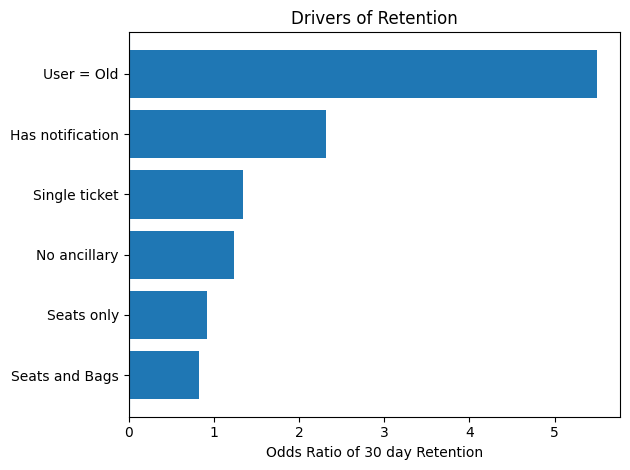

In [55]:
import matplotlib.pyplot as plt

plt.barh(or_df["variable"], or_df["odds_ratio"])
plt.axvline(0)

plt.xlabel("Odds Ratio of 30 day Retention")
plt.title("Drivers of Retention")

plt.tight_layout()
plt.show()

## Additional calls per offer

In [49]:
call_model = smf.ols(
    "y_total_calls_with_duration_after_notification ~ has_notification_int + has_cancel_notification_int + C(user_type) + C(ticket_group) + C(ancillary_group)",
    data=df_stratified
).fit(cov_type="HC3")

print(call_model.summary())

                                          OLS Regression Results                                          
Dep. Variable:     y_total_calls_with_duration_after_notification   R-squared:                       0.003
Model:                                                        OLS   Adj. R-squared:                  0.003
Method:                                             Least Squares   F-statistic:                     124.6
Date:                                            Fri, 16 Jan 2026   Prob (F-statistic):          6.22e-184
Time:                                                    19:54:28   Log-Likelihood:             3.5095e+05
No. Observations:                                          614139   AIC:                        -7.019e+05
Df Residuals:                                              614131   BIC:                        -7.018e+05
Df Model:                                                       7                                         
Covariance Type:                     

In [50]:
df_cf = df_stratified.copy()

# Preserve original cancel flags
orig_cancel = df_cf["has_cancel_notification_int"].fillna(0).astype(int)

# ---------------------------
# Scenario 0: No notifications
# ---------------------------
df_cf["has_notification_int"] = 0
df_cf["has_cancel_notification_int"] = 0
calls_no_notif = call_model.predict(df_cf)

# -------------------------------------------------------------------
# Scenario 1: All offers get notification, but NONE are cancellation
# -------------------------------------------------------------------
df_cf["has_notification_int"] = 1
df_cf["has_cancel_notification_int"] = 0
calls_all_notif_no_cancel = call_model.predict(df_cf)

# ---------------------------------------------------------------------------------------
# Scenario 2: All offers get notification, and original cancel-notification offers stay cancel
# ---------------------------------------------------------------------------------------
df_cf["has_notification_int"] = 1
df_cf["has_cancel_notification_int"] = orig_cancel
calls_all_notif_keep_cancel = call_model.predict(df_cf)

# ---------------------------
# Summarize incremental calls
# ---------------------------
n = len(df_cf)

summary_calls = pd.DataFrame({
    "scenario": [
        "No notifications",
        "All notifications, no cancels",
        "All notifications",
    ],
    "expected_calls": [
        calls_no_notif.sum(),
        calls_all_notif_no_cancel.sum(),
        calls_all_notif_keep_cancel.sum(),
    ],
})

summary_calls["calls_per_offer"] = summary_calls["expected_calls"] / n

# Increment vs no notifications baseline
baseline_calls = summary_calls.loc[0, "expected_calls"]

summary_calls["incremental_calls_vs_none"] = (
    summary_calls["expected_calls"] - baseline_calls
)

summary_calls["incremental_calls_per_offer_vs_none"] = (
    summary_calls["incremental_calls_vs_none"] / n
)

summary_calls["incremental_calls_per_1000_offers_vs_none"] = (
    summary_calls["incremental_calls_per_offer_vs_none"] * 1000
)

summary_calls

,scenario,expected_calls,calls_per_offer,incremental_calls_vs_none,incremental_calls_per_offer_vs_none,incremental_calls_per_1000_offers_vs_none
0,No notifications,12506.945504,0.020365,0.000000,0.000000,0.000000
1,"All notifications, no cancels",10940.714593,0.017815,-1566.230911,-0.002550,-2.550287
2,All notifications,11635.468212,0.018946,-871.477292,-0.001419,-1.419023


In [54]:
# Extract coefficient table from statsmodels OLS
coef_table = call_model.summary().tables[1]


In [55]:
coef_table 

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.0109,0.001,8.185,0.000,0.008,0.014
C(user_type)[T.Old],0.0016,0.000,4.395,0.000,0.001,0.002
C(ticket_group)[T.Single ticket],-0.0010,0.000,-2.498,0.012,-0.002,-0.000
C(ancillary_group)[T.No ancillary],0.0104,0.001,9.461,0.000,0.008,0.013
C(ancillary_group)[T.Seats and Bags],0.0012,0.002,0.660,0.509,-0.002,0.005
C(ancillary_group)[T.Seats only],0.0044,0.001,3.904,0.000,0.002,0.007
has_notification_int,-0.0026,0.001,-3.369,0.001,-0.004,-0.001
has_cancel_notification_int,0.0495,0.002,23.349,0.000,0.045,0.054


## Logit Regression on Strata (Flight Rebook)

In [56]:
model = smf.logit(
    "y_flight_rebook ~ has_notification_int + has_cancel_notification_int + C(offer_type) + C(user_type) + C(ticket_group) + C(ancillary_group)",
    data=df_stratified
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.113735
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:        y_flight_rebook   No. Observations:               614139
Model:                          Logit   Df Residuals:                   614130
Method:                           MLE   Df Model:                            8
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.03794
Time:                        14:46:55   Log-Likelihood:                -69849.
converged:                       True   LL-Null:                       -72603.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -6.4056      0.1

In [58]:
coef = {
    "Offer type = Semi-Opaque": 0.3332,
    "User type = Old": 1.1989,
    "Ticket group = Single ticket": 0.5523,
    "Ancillary = No ancillary": 0.0746,
    "Ancillary = Seats and Bags": -0.3377,
    "Ancillary = Seats only": -0.1729,
    "Has notification": 1.3083,
    "Has cancellation notification": 0.7840,
}

flight_rebook_or_df = (
    pd.DataFrame.from_dict(coef, orient="index", columns=["logit_coef"])
    .assign(odds_ratio=lambda x: np.exp(x["logit_coef"]))
    .reset_index()
    .rename(columns={"index": "factor"})
)

flight_rebook_or_df

,factor,logit_coef,odds_ratio
0,Offer type = Semi-Opaque,0.3332,1.395426
1,User type = Old,1.1989,3.316467
2,Ticket group = Single ticket,0.5523,1.737244
3,Ancillary = No ancillary,0.0746,1.077453
4,Ancillary = Seats and Bags,-0.3377,0.713409
5,Ancillary = Seats only,-0.1729,0.841222
6,Has notification,1.3083,3.699879
7,Has cancellation notification,0.7840,2.190216


In [60]:
### Flight Rebook Rate for Notifications and no cancel
p0 = df_stratified.loc[
    (df_stratified["has_notification_int"] == 1) &
    (df_stratified["has_cancel_notification_int"] == 0),
    "y_flight_rebook"
].mean()

p0

0.02590934745645391

## Data checks

In [57]:
## Placebo
anchor_date = df_stratified["first_notification_date"].fillna(
    df_stratified["travel_start_date"]
)

valid_mask = df_stratified["next_non_notif_flight_submit_date_time"].notna()

(
    df_stratified.loc[valid_mask, "next_non_notif_flight_submit_date_time"]
    >= anchor_date.loc[valid_mask]
).mean()

0.9931059648391175

In [79]:
## Placebo

df_stratified["y_placebo"] = (
    df_stratified["next_product_desc"] == 'RENTAL CAR'
).astype(int)

In [80]:
model = smf.logit(
    "y_placebo ~ has_notification_int + has_cancel_notification_int + C(user_type) + C(ticket_group) + C(ancillary_group)",
    data=df_stratified
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.111585
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              y_placebo   No. Observations:               614139
Model:                          Logit   Df Residuals:                   614131
Method:                           MLE   Df Model:                            7
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                 0.03444
Time:                        15:18:46   Log-Likelihood:                -68529.
converged:                       True   LL-Null:                       -70973.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -5.1440      0.0